# Notebook 4 - Age-specific impact functions for heat mortality

This notebook converts the daily `T2M` hazard and age-specific exposures prepared in the previous notebooks into age-differentiated heat-mortality impact functions (IFs) that can be used in CLIMADA. The workflow has four main steps: load and repair the hazard / exposure inputs, parameterise age-specific heat-response curves from Burke et al. (2025) Figure 2 for Europe, run both a transparent city-mean diagnostic and the full pixel-wise CLIMADA calculation, and then scale the IF level through time using projected baseline mortality from WCDE / Wittgenstein.

One modelling choice needs to be stated clearly. The notebook does **not** estimate a new epidemiological model. Instead, it approximates the published Burke et al. figure by eye. The main specification uses a polynomial heat-response curve; a power-law family is kept as a sensitivity and legacy comparison. Because this calibration step is judgement-based, the notebook makes the assumptions explicit, runs several sensitivity checks, and exports the IF artifacts that are later reused in the adaptation and uncertainty notebooks.

The outputs written here include reference-year and year-specific IF JSON files, annual heat-death tables, baseline-mortality scaling factors, and sensitivity diagnostics used downstream in the AC, EWS, vegetation, CBA, and uncertainty notebooks.


In [1]:
import os
os.environ["CITY"] = "Athens"   # pick the city here


In [2]:
# Bootstrap repo paths and the city-specific YAML configuration.
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Resolve the city slug from notebook globals or environment.
SLUG = globals().get("SLUG", os.environ.get("CITY", "Athens")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: Athens  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/athens  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim


In [3]:
cfg  = C.get("cfg")     # dict loaded from YAML

## Inputs from previous notebooks

This notebook starts from the harmonised products created in `NB02` and `NB03`. It loads:

- the daily `T2M` hazard object and its event table;
- age-specific exposure objects for `2020`, `2030`, `2040`, and `2050`;
- the city mask and gridded age arrays needed to rebuild the direct 2030 exposure if that file is missing.

The aim of this first block is simply to recover clean, year-specific CLIMADA-ready inputs before any impact-function work begins.


In [4]:
print((INT / f"age_on_ref_{SLUG}_2030.npz").exists())
print((INT / "city_mask.npz").exists())
print((INT / "exposure_manifest.json").exists())

True
True
True


In [5]:
# Load age-specific exposures for each target year, rebuilding the direct 2030 file if needed.
from climada.entity.exposures import Exposures
import numpy as np
import json
from pathlib import Path

SCEN = "SSP2"
YEARS = [2020, 2030, 2040, 2050]

def ensure_direct_2030_exposure_exists(SLUG=SLUG, INT=INT, OUT=OUT):
    candidates = [
        OUT / f"exposure_with_vulnerability_{SLUG}_2030.h5",
        INT / f"exposure_with_vulnerability_{SLUG}_2030.h5",
    ]
    for p in candidates:
        if p.exists():
            print(f"→ Found direct 2030 exposure: {p}")
            return p

    base_p = INT / f"exposure_with_vulnerability_{SLUG}.h5"
    if not base_p.exists():
        base_p = OUT / f"exposure_with_vulnerability_{SLUG}.h5"
    if not base_p.exists():
        raise FileNotFoundError(f"Missing baseline exposure template: {base_p}")

    exp2030 = Exposures.from_hdf5(base_p)

    age_npz_candidates = [
        INT / f"age_on_ref_{SLUG}_2030.npz",
    ]

    manifest_p = INT / "exposure_manifest.json"
    if manifest_p.exists():
        with open(manifest_p, "r") as f:
            manifest = json.load(f)
        try:
            age_npz_candidates.append(Path(manifest["direct_worldpop"]["2030"]["age_npz"]))
        except Exception:
            pass

    age_npz_path = next((p for p in age_npz_candidates if p.exists()), None)
    if age_npz_path is None:
        raise FileNotFoundError(
            "Could not find 2030 age grids from NB2. "
            "Expected something like age_on_ref_<slug>_2030.npz in interim."
        )

    city_mask_p = INT / "city_mask.npz"
    if not city_mask_p.exists():
        raise FileNotFoundError(f"Missing city mask: {city_mask_p}")
    CITY_MASK = np.load(city_mask_p)["city_mask"].astype(bool)

    age_npz = np.load(age_npz_path)
    arr_map = {
        "<15":   age_npz["lt15"],
        "15-64": age_npz["a15_64"],
        "65+":   age_npz["g65"],
    }

    if "age_group" not in exp2030.gdf.columns:
        raise KeyError("Exposure gdf has no 'age_group' column.")

    # Update the baseline exposure template with the 2030 age grids cell by cell.
    for grp, arr in arr_map.items():
        vals = arr[CITY_MASK].ravel().astype(float)
        idx = exp2030.gdf.index[exp2030.gdf["age_group"] == grp]

        if len(idx) != len(vals):
            raise ValueError(
                f"Row mismatch for {grp}: exposure rows={len(idx)} vs grid cells={len(vals)}"
            )

        exp2030.gdf.loc[idx, "value"] = vals

    exp2030.ref_year = 2030

    out_2030 = OUT / f"exposure_with_vulnerability_{SLUG}_2030.h5"
    exp2030.write_hdf5(out_2030)
    print(f"→ Built missing direct 2030 exposure: {out_2030}")
    return out_2030


def load_exposure_by_year(scen_code=SCEN, years=YEARS, SLUG=SLUG):
    exps = {}

    p2020 = INT / f"exposure_with_vulnerability_{SLUG}.h5"
    if not p2020.exists():
        p2020 = OUT / f"exposure_with_vulnerability_{SLUG}.h5"
    if not p2020.exists():
        raise FileNotFoundError(f"Missing baseline exposure for 2020: {p2020}")

    p2030 = ensure_direct_2030_exposure_exists(SLUG=SLUG, INT=INT, OUT=OUT)

    for y in years:
        if y == 2020:
            p = p2020
            label = "BASE"
        elif y == 2030:
            p = p2030
            label = "DIRECT"
        else:
            p = OUT / f"exposure_with_vulnerability_{SLUG}_{scen_code}_{y}.h5"
            if not p.exists():
                p = INT / f"exposure_with_vulnerability_{SLUG}_{scen_code}_{y}.h5"
            if not p.exists():
                raise FileNotFoundError(f"Expected exposure file not found: {p}")
            label = scen_code

        print(f"→ Loaded exposure for {label} {y}: {p}")
        exps[y] = Exposures.from_hdf5(p)

    return exps

exposures_by_year = load_exposure_by_year()

→ Found direct 2030 exposure: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/exposure_with_vulnerability_athens_2030.h5
→ Loaded exposure for BASE 2020: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/exposure_with_vulnerability_athens.h5
→ Loaded exposure for DIRECT 2030: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/exposure_with_vulnerability_athens_2030.h5
→ Loaded exposure for SSP2 2040: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/exposure_with_vulnerability_athens_SSP2_2040.h5
→ Loaded exposure for SSP2 2050: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/exposure_with_vulnerability_athens_SSP2_2050.h5


In [6]:
# Load the daily T2M hazard produced earlier in the pipeline.
import pandas as pd
from climada.hazard import Hazard

haz_candidates = [
    INT / f"hazard_T2M_daily_{SLUG}.h5",
    OUT / f"hazard_T2M_daily_{SLUG}.h5",
]

haz_path = next((p for p in haz_candidates if p.exists()), None)
if haz_path is None:
    raise FileNotFoundError(
        f"Could not find hazard file for {SLUG}. Looked for: "
        + ", ".join(str(p) for p in haz_candidates)
    )

H = Hazard.from_hdf5(haz_path)
print(f"→ Loaded hazard: {haz_path}")
print(f"  events: {H.intensity.shape[0]}")
print(f"  cells:  {H.intensity.shape[1]}")

→ Loaded hazard: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/hazard_T2M_daily_athens.h5
  events: 1462
  cells:  90601


In [7]:
# Reattach daily dates and per-year frequencies from the NB03 event table.
def _days_in_year(y):
    return 366 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 365

def reattach_daily_dates(INT, SLUG, H):
    csv = INT / f"hazard_T2M_daily_events_{SLUG}.csv"
    df = pd.read_csv(csv).sort_values("row").reset_index(drop=True)

    n = H.intensity.shape[0]
    assert len(df) == n, f"Events CSV rows ({len(df)}) != hazard rows ({n})."

    H.event_id   = df["event_id"].to_numpy(int)
    H.date       = pd.to_datetime(df["date"]).to_numpy("datetime64[ns]")
    H.event_name = np.array([f"T2M_{d.date()}" for d in pd.to_datetime(df["date"])], dtype=object)

    yrs = pd.to_datetime(df["date"]).dt.year.to_numpy(int)
    H.frequency      = np.array([1.0/_days_in_year(y) for y in yrs], dtype=float)
    H.frequency_unit = "1/year"
    return H

H = reattach_daily_dates(INT, SLUG, H)
H.haz_type = "T2M"
H.units    = "degC (daily mean)"

yrs = pd.to_datetime(H.date).year.to_numpy(int)
print(pd.Series(yrs).value_counts().sort_index())
print(pd.DataFrame({"y": yrs, "f": H.frequency}).groupby("y")["f"].sum())

assert np.allclose(pd.DataFrame({"y": yrs, "f": H.frequency}).groupby("y")["f"].sum().values, 1.0)

if not hasattr(H, "date") or len(getattr(H, "date", [])) != H.intensity.shape[0]:
    raise RuntimeError("Daily dates not present in hazard. Re-run NB3 saving steps.")

dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
year_idx = dates.dt.year.to_numpy(int)

2020    366
2030    365
2040    366
2050    365
Name: count, dtype: int64
y
2020    1.0
2030    1.0
2040    1.0
2050    1.0
Name: f, dtype: float64


In [8]:
# Compute a city-mean daily T2M diagnostic using the hazard mask / fraction arrays.
num = H.intensity.multiply(H.fraction).sum(axis=1)   # sum of T over valid cells
den = H.fraction.sum(axis=1)                         # number of valid cells
citymean_daily = (num / den).A1                      # 1D array (length = n_days)

pd.DataFrame({"date": dates, "citymean_degC": citymean_daily}).head(10)

,date,citymean_degC
0,2020-01-01,7.808971
1,2020-01-02,8.935960
2,2020-01-03,9.885722
3,2020-01-04,9.731815
4,2020-01-05,9.896791
5,2020-01-06,9.464127
6,2020-01-07,8.478910
7,2020-01-08,8.182672
8,2020-01-09,8.637845
9,2020-01-10,8.960084


## Diagnostic check on the daily hazard

Before calibrating the impact functions, we inspect the city-mean daily `T2M` series as a simple diagnostic. This is **not** the final impact calculation. It is just a quick way to verify that the repaired hazard has the expected seasonal structure and to see which temperature range the city actually reaches before moving to the full grid-based analysis.


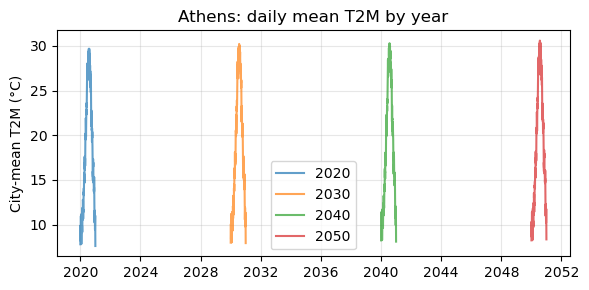

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
# daily city-mean T2M per year (just for intuition)
daily_df = pd.DataFrame({"date": dates, "citymean_degC": citymean_daily})
daily_df["year"] = daily_df["date"].dt.year

fig, ax = plt.subplots(figsize=(6,3))
for y, sub in daily_df.groupby("year"):
    ax.plot(sub["date"], sub["citymean_degC"], label=y, alpha=0.7)
ax.set_ylabel("City-mean T2M (°C)")
ax.set_title(f"{CITY}: daily mean T2M by year")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Common temperature axis and reference temperature

All age-specific IFs are defined on the same `0-40 °C` temperature grid. The current default reference / onset temperature is `20 °C`: below that value, the notebook sets heat-attributable mortality to zero; above it, the fitted heat tail rises. This threshold is a modelling assumption rather than an estimated city-specific minimum-mortality temperature, so it is revisited later in the sensitivity section.


In [10]:
# Shared temperature axis used for all age-specific T2M impact functions.
t_min, t_max, t_step = 0.0, 40.0, 0.5
T_grid = np.arange(t_min, t_max + 1e-6, t_step)  # °C
T_ref  = 20.0  # "comfortable" temperature, where excess risk is around 0

## From Burke-style deaths per 100k to CLIMADA `mdd`

CLIMADA expects each impact function to provide `mdd`, the fraction of exposed people who die during an event. The Burke-style figure used here is interpreted in units of **extra deaths per 100,000 people per hot day** relative to the reference temperature. The notebook therefore converts those values to a per-person daily probability by dividing by `100,000`, keeping the curve heat-only and clipping the final `mdd` to `[0, 1]`.


Two hot-side curve families are implemented above `T_ref`: a polynomial response used as the main specification, and a convex power-law response retained for sensitivity and legacy comparison. Both are constrained to be zero below the reference temperature so that the notebook isolates heat-attributable mortality rather than modelling the full cold-and-heat mortality relationship.


In [11]:
def heat_tail_power(T, T_ref, d1, T1, d2, T2):
    """
    Constructing a convex 'heat-only' curve:
      change deaths per 100k = beta * (T - T_ref)^p  for T > T_ref, else 0
    passing approximately through (T1, d1) and (T2, T2).
    """
    # distance above reference
    h1 = max(T1 - T_ref, 1e-6)
    h2 = max(T2 - T_ref, 1e-6)
    # exponent from the two target points
    p = np.log(d2 / d1) / np.log(h2 / h1)
    beta = d1 / (h1 ** p)
    out = np.zeros_like(T, dtype=float)
    h = np.clip(T - T_ref, 0, None)
    out = beta * np.power(h, p)
    return out, beta, p


def heat_tail_polynomial(T, T_ref, ref_points, degree=4):
    """
    Fit a polynomial heat-only curve (like Burke et al. 2025):
      Δ deaths per 100k = Σ c_i * (T - T_ref)^i  for T > T_ref, else 0
    
    Parameters
    ----------
    T : array
        Temperature grid
    T_ref : float
        Reference temperature (MMT, ~20°C)
    ref_points : list of tuples
        [(T1, d1), (T2, d2), ...] reference points to fit through
    degree : int
        Polynomial degree (Burke et al. use 4)
    
    Returns
    -------
    out : array
        Δ deaths per 100k at each T
    coeffs : array
        Polynomial coefficients [c1, c2, ..., c_degree]
    """
    from numpy.polynomial import polynomial as P
    
    # Extract reference points
    T_pts = np.array([p[0] for p in ref_points])
    d_pts = np.array([p[1] for p in ref_points])
    
    # Transform to distance above T_ref
    h_pts = T_pts - T_ref
    
    # Add the origin (at T_ref, excess deaths = 0)
    h_pts = np.concatenate([[0], h_pts])
    d_pts = np.concatenate([[0], d_pts])
    
    # Fit polynomial (no constant term - curve passes through origin)
    # We fit: d = c1*h + c2*h^2 + c3*h^3 + c4*h^4
    # Using least squares with the constraint that d(0) = 0
    
    # Build design matrix for h, h^2, h^3, h^4 (no intercept)
    H_matrix = np.column_stack([h_pts**i for i in range(1, degree + 1)])
    
    # Solve least squares
    coeffs, residuals, rank, s = np.linalg.lstsq(H_matrix, d_pts, rcond=None)
    
    # Evaluate on full T grid
    h = np.clip(T - T_ref, 0, None)
    out = np.zeros_like(T, dtype=float)
    for i, c in enumerate(coeffs, start=1):
        out += c * np.power(h, i)
    
    # Ensure non-negative (small numerical issues possible)
    out = np.clip(out, 0, None)
    
    return out, coeffs


# Choose functional form
USE_POLYNOMIAL = True  # Set to False to use power-law instead

if USE_POLYNOMIAL:
    print("Using POLYNOMIAL functional form (à la Burke et al. 2025)")
else:
    print("Using POWER-LAW functional form")

Using POLYNOMIAL functional form (à la Burke et al. 2025)


## Calibration logic

The calibration is intentionally transparent:

1. Read age-specific response levels by eye from Burke et al. (2025) Figure 2, EU panel.
2. Translate those visual readings into age-specific anchor points in units of extra deaths per 100,000 people per day.
3. Fit a smooth heat-only curve above `T_ref`.
4. Convert the fitted curve into `mdd(T)` so it can be passed to CLIMADA.

This makes the judgement step explicit instead of hiding it. The notebook then stress-tests the implications of those choices later through dedicated sensitivity analyses.


### Source and interpretation of the anchor points

The anchor points below are **not** raw coefficients reported by Burke et al. and they are **not** re-estimated from raw mortality data in this notebook. They are approximate values read by eye from the EU panel of Burke et al. (2025) Figure 2 and used as a pragmatic calibration target. That is why the notebook later varies anchor scale, functional form, and onset temperature, and why `NB09` carries IF uncertainty explicitly.


### Anchor points used in the main calibration

The current polynomial main specification uses the following approximate anchor points, expressed as extra deaths per 100,000 people per day above the reference temperature:

- `65+`: `(22, 0.1)`, `(25, 0.5)`, `(28, 1.5)`, `(30, 3.5)`, `(33, 7.0)`, `(35, 12.0)`
- `15-64`: `(22, 0.0)`, `(25, 0.02)`, `(28, 0.05)`, `(30, 0.15)`, `(33, 0.40)`, `(35, 0.80)`
- `<15`: `(22, 0.0)`, `(25, 0.005)`, `(28, 0.02)`, `(30, 0.03)`, `(33, 0.04)`, `(35, 0.05)`

Qualitatively, this encodes a steeply increasing elderly response, a much flatter adult response that rises mainly at higher temperatures, and a near-zero response for the youngest age group.


In [12]:
# Approximate calibration anchor points read by eye from Burke et al. (2025), Figure 2, EU panel.
# Reference: "Understanding and Addressing Temperature Impacts on Mortality"

# Reference points approximated from the Burke et al. EU panel.
# Format: (temperature °C, extra deaths per 100k people per day)

# 65+: strongest convex heat response in the visual calibration target
elderly_ref_points = [
    (22, 0.1),    # just above T_ref, very small effect
    (25, 0.5),    # modest effect
    (28, 1.5),    # growing
    (30, 3.5),    # substantial
    (33, 7.0),    # high
    (35, 12.0),   # very high
]

# 15-64: small response that rises mainly on hotter days
adult_ref_points = [
    (22, 0.0),
    (25, 0.02),
    (28, 0.05),
    (30, 0.15),
    (33, 0.40),
    (35, 0.80),
]

# <15: near-flat response in the visual calibration target
young_ref_points = [
    (22, 0.0),
    (25, 0.005),
    (28, 0.02),
    (30, 0.03),
    (33, 0.04),
    (35, 0.05),
]

if USE_POLYNOMIAL:
    # Polynomial fit (Burke et al. style)
    elderly_d, elderly_coeffs = heat_tail_polynomial(T_grid, T_ref, elderly_ref_points, degree=4)
    adult_d, adult_coeffs = heat_tail_polynomial(T_grid, T_ref, adult_ref_points, degree=4)
    young_d, young_coeffs = heat_tail_polynomial(T_grid, T_ref, young_ref_points, degree=4)
    
    print("=== POLYNOMIAL Calibration (Burke et al. 2025 style) ===")
    print(f"\nElderly coeffs (c1..c4): {elderly_coeffs}")
    print(f"Adult coeffs (c1..c4):   {adult_coeffs}")
    print(f"Young coeffs (c1..c4):   {young_coeffs}")
else:
    # Power-law fit (original approach)
    elderly_d, elderly_beta, elderly_p = heat_tail_power(
        T_grid, T_ref, d1=3.5, T1=30.0, d2=12.0, T2=35.0)
    adult_d, adult_beta, adult_p = heat_tail_power(
        T_grid, T_ref, d1=0.05, T1=28.0, d2=0.80, T2=35.0)
    young_d, young_beta, young_p = heat_tail_power(
        T_grid, T_ref, d1=0.02, T1=28.0, d2=0.05, T2=35.0)
    
    print("=== POWER-LAW Calibration ===")
    print(f"\nElderly: beta={elderly_beta:.6f}, p={elderly_p:.3f}")
    print(f"Adult:   beta={adult_beta:.6f}, p={adult_p:.3f}")
    print(f"Young:   beta={young_beta:.6f}, p={young_p:.3f}")

# Converting to mdd (per-person daily probability)
per100k = 100_000.0
elderly_mdd = elderly_d / per100k
adult_mdd   = adult_d   / per100k
young_mdd   = young_d   / per100k

# Clip to [0, 1]
elderly_mdd = np.clip(elderly_mdd, 0, 1)
adult_mdd   = np.clip(adult_mdd,   0, 1)
young_mdd   = np.clip(young_mdd,   0, 1)

# Verification: print values at key temperatures
print("\n=== Verification (deaths per 100k) ===")
for T_check in [22, 25, 28, 30, 33, 35]:
    e_val = np.interp(T_check, T_grid, elderly_d)
    a_val = np.interp(T_check, T_grid, adult_d)
    y_val = np.interp(T_check, T_grid, young_d)
    print(f"  {T_check}°C:  Elderly={e_val:6.2f}  Adult={a_val:5.2f}  Young={y_val:5.3f}")

=== POLYNOMIAL Calibration (Burke et al. 2025 style) ===

Elderly coeffs (c1..c4): [-0.08799001  0.05547878 -0.00499176  0.00034802]
Adult coeffs (c1..c4):   [-8.70721302e-03  5.04131587e-03 -7.28209907e-04  4.44685992e-05]
Young coeffs (c1..c4):   [-2.70141261e-03  1.15022412e-03 -7.79274066e-05  1.86226953e-06]

=== Verification (deaths per 100k) ===
  22°C:  Elderly=  0.01  Adult= 0.00  Young=0.000
  25°C:  Elderly=  0.54  Adult= 0.02  Young=0.007
  28°C:  Elderly=  1.72  Adult= 0.06  Young=0.020
  30°C:  Elderly=  3.16  Adult= 0.13  Young=0.029
  33°C:  Elderly=  7.20  Adult= 0.41  Young=0.041
  35°C:  Elderly= 11.93  Adult= 0.80  Young=0.050


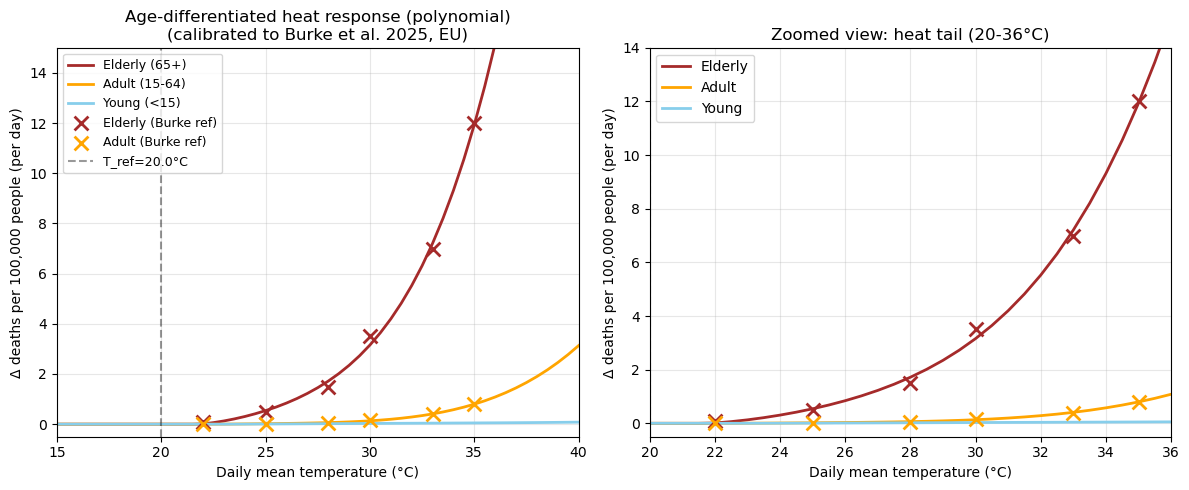


Functional form: POLYNOMIAL
Polynomial coefficients [c1, c2, c3, c4] for d = c1*h + c2*h² + c3*h³ + c4*h⁴:
  Elderly: [-0.08799001  0.05547878 -0.00499176  0.00034802]
  Adult:   [-8.70721302e-03  5.04131587e-03 -7.28209907e-04  4.44685992e-05]
  Young:   [-2.70141261e-03  1.15022412e-03 -7.79274066e-05  1.86226953e-06]


In [13]:
# Validation plot: compare fitted curves to Burke et al. (2025) EU reference points

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: Full curves with reference points
ax = axes[0]
ax.plot(T_grid, elderly_d, label="Elderly (65+)", color="brown", lw=2)
ax.plot(T_grid, adult_d, label="Adult (15-64)", color="orange", lw=2)
ax.plot(T_grid, young_d, label="Young (<15)", color="skyblue", lw=2)

# Plot the reference points used for fitting
elderly_T = [p[0] for p in elderly_ref_points]
elderly_vals = [p[1] for p in elderly_ref_points]
adult_T = [p[0] for p in adult_ref_points]
adult_vals = [p[1] for p in adult_ref_points]

ax.scatter(elderly_T, elderly_vals, c="brown", marker="x", s=100, lw=2, 
           label="Elderly (Burke ref)", zorder=5)
ax.scatter(adult_T, adult_vals, c="orange", marker="x", s=100, lw=2,
           label="Adult (Burke ref)", zorder=5)

ax.axvline(T_ref, color="k", linestyle="--", alpha=0.4, label=f"T_ref={T_ref}°C")
ax.set_xlim(15, 40)
ax.set_ylim(-0.5, 15)
ax.set_xlabel("Daily mean temperature (°C)")
ax.set_ylabel("Δ deaths per 100,000 people (per day)")
form_label = "polynomial" if USE_POLYNOMIAL else "power-law"
ax.set_title(f"Age-differentiated heat response ({form_label})\n(calibrated to Burke et al. 2025, EU)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=9)

# Right panel: Zoom on 20-35°C range (where most action is)
ax2 = axes[1]
ax2.plot(T_grid, elderly_d, label="Elderly", color="brown", lw=2)
ax2.plot(T_grid, adult_d, label="Adult", color="orange", lw=2)
ax2.plot(T_grid, young_d, label="Young", color="skyblue", lw=2)

ax2.scatter(elderly_T, elderly_vals, c="brown", marker="x", s=100, lw=2, zorder=5)
ax2.scatter(adult_T, adult_vals, c="orange", marker="x", s=100, lw=2, zorder=5)

ax2.axvline(T_ref, color="k", linestyle="--", alpha=0.4)
ax2.set_xlim(20, 36)
ax2.set_ylim(-0.5, 14)
ax2.set_xlabel("Daily mean temperature (°C)")
ax2.set_ylabel("Δ deaths per 100,000 people (per day)")
ax2.set_title("Zoomed view: heat tail (20-36°C)")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_IF_calibration_burke_{form_label}.png", dpi=150)
plt.show()

print(f"\nFunctional form: {form_label.upper()}")
if USE_POLYNOMIAL:
    print("Polynomial coefficients [c1, c2, c3, c4] for d = c1*h + c2*h² + c3*h³ + c4*h⁴:")
    print(f"  Elderly: {elderly_coeffs}")
    print(f"  Adult:   {adult_coeffs}")
    print(f"  Young:   {young_coeffs}")

## Age-specific population totals by year

The exposure objects prepared earlier already contain the age-specific population counts on the analysis grid. Here we aggregate them to city totals for each target year. These totals are used twice: first in the simple city-mean diagnostic, and later in the full CLIMADA calculation when impacts are computed separately for `<15`, `15-64`, and `65+`.


In [14]:
# Aggregate total exposed population by age group and year from the prepared exposure objects.

# Build a [year x age_group] table of city-level populations on the analysis grid.
age_pop_by_year = (
    pd.concat(
        {
            year: exp_y.gdf
                       .groupby("age_group")["value"]
                       .sum()
                       .astype(float)
            for year, exp_y in exposures_by_year.items()
        },
        axis=1,
    )
    .T  # years as rows
    .sort_index()
)

print(f"Population by age group (T2M grid, scenario {SCEN}):")
print(age_pop_by_year)
print("Total population per year:")
print(age_pop_by_year.sum(axis=1))

# Keep a 2020 baseline vector for backwards compatibility with the legacy code below.
age_pop = age_pop_by_year.loc[2020].sort_index()
print("\nUsing 2020 age_pop as baseline for some diagnostics;")
print("full time-varying populations are in `age_pop_by_year`.")

Population by age group (T2M grid, scenario SSP2):
age_group         15-64           65+            <15
2020       2.270311e+06  6.931959e+05  461141.021367
2030       2.108793e+06  7.863061e+05  362729.251140
2040       1.903635e+06  9.177195e+05  344899.241820
2050       1.715073e+06  1.021987e+06  356424.231396
Total population per year:
2020    3.424648e+06
2030    3.257828e+06
2040    3.166253e+06
2050    3.093484e+06
dtype: float64

Using 2020 age_pop as baseline for some diagnostics;
full time-varying populations are in `age_pop_by_year`.


## Interpolating the fitted curves

Once the age-specific curves are defined on `T_grid`, we build helper functions that return `Δ deaths per 100k` for any daily mean temperature. This keeps the manual diagnostic transparent and makes the unit conversion explicit before switching to CLIMADA's `mdd` formulation.


In [15]:
import numpy as np
import pandas as pd

# Map each age group to its fitted diagnostic curve in deaths per 100k per day.
curves_per100k = {
    "<15":   young_d,
    "15-64": adult_d,
    "65+":   elderly_d,
}

def delta_deaths_per100k(T):
    """
    Return a dict {age_group: Δ deaths per 100k per day} 
    for a scalar temperature T (°C).
    """
    out = {}
    for age, curve in curves_per100k.items():
        out[age] = float(np.interp(T, T_grid, curve))
    return out

## Manual diagnostic using city-mean temperature

This block provides a transparent city-level check rather than the final estimate. For each day, the notebook applies the city-mean temperature to the fitted age-specific curves and multiplies the resulting excess-death rate by the corresponding age-group population. Because it ignores within-city temperature heterogeneity, it is expected to differ slightly from the final CLIMADA results.


In [16]:
# Build one row per day and age group using the city-mean temperature diagnostic.
df = pd.DataFrame({
    "date": dates,
    "temp_degC": citymean_daily,
})
df["year"] = df["date"].dt.year

rows = []
for _, row in df.iterrows():
    T = row["temp_degC"]
    y = row["year"]
    d_per100k = delta_deaths_per100k(T)
    for age in ["<15", "15-64", "65+"]:
        deaths_day = d_per100k[age] * (age_pop_by_year.loc[y, age] / 100_000.0)
        rows.append({
            "date":  row["date"],
            "year":  y,
            "age_group": age,
            "temp_degC": T,
            "delta_deaths": deaths_day,
        })

daily_heat = pd.DataFrame(rows)

In [17]:
daily_heat = pd.DataFrame(rows)

# look at the first few days
print(daily_heat.head())

        date  year age_group  temp_degC  delta_deaths
0 2020-01-01  2020       <15   7.808971           0.0
1 2020-01-01  2020     15-64   7.808971           0.0
2 2020-01-01  2020       65+   7.808971           0.0
3 2020-01-02  2020       <15   8.935960           0.0
4 2020-01-02  2020     15-64   8.935960           0.0


In [18]:
# Aggregate the manual diagnostic to annual heat deaths by age group.
yearly = (
    daily_heat
    .groupby(["year", "age_group"])["delta_deaths"]
    .sum()
    .unstack("age_group")          # columns: '<15', '15-64', '65+'
    .fillna(0.0)
)

# Rename columns for readability.
yearly = yearly.rename(
    columns={
        "<15":   "deaths_young",
        "15-64": "deaths_adult",
        "65+":   "deaths_elderly",
    }
)

# Add totals across the three age groups.
yearly["deaths_total"] = (
    yearly["deaths_young"]
    + yearly["deaths_adult"]
    + yearly["deaths_elderly"]
)

print(yearly)

age_group  deaths_adult  deaths_elderly  deaths_young  deaths_total
year                                                               
2020         134.932565     1114.492535      8.274063   1257.699163
2030         145.101556     1432.432218      7.144053   1584.677827
2040         136.943151     1737.663008      7.004194   1881.610353
2050         138.160813     2125.700845      7.730748   2271.592405


## Aggregate annual deaths and annual rates

Daily excess deaths are summed to annual totals by age group. The notebook also computes annual rates per 100,000 within each age group, which makes it easier to compare the response across populations of very different sizes.


In [19]:
# Report annual totals and within-age-group rates per 100k.
annual_by_age = (
    daily_heat
    .groupby(["year", "age_group"])["delta_deaths"]
    .sum()
    .unstack("age_group")
)

print("Annual heat deaths (absolute):")
print(annual_by_age)

# Annual rates per 100k in each age group
annual_rates_per100k = annual_by_age.copy()
for age in ["<15", "15-64", "65+"]:
    # The population Series is indexed by year, so the division aligns automatically.
    annual_rates_per100k[age] = (
        annual_by_age[age] / (age_pop_by_year[age] / 100_000.0)
    )

print("\nAnnual heat deaths per 100k, by age group:")
print(annual_rates_per100k)

Annual heat deaths (absolute):
age_group       15-64          65+       <15
year                                        
2020       134.932565  1114.492535  8.274063
2030       145.101556  1432.432218  7.144053
2040       136.943151  1737.663008  7.004194
2050       138.160813  2125.700845  7.730748

Annual heat deaths per 100k, by age group:
age_group     15-64         65+       <15
year                                     
2020       5.943352  160.775981  1.794259
2030       6.880788  182.172340  1.969528
2040       7.193773  189.345772  2.030794
2050       8.055680  207.996948  2.168974


## Full CLIMADA implementation on the grid

The final impact calculation is spatially explicit. The fitted age-specific `mdd(T)` curves are converted into CLIMADA `ImpactFunc` objects, exposures are filtered by age group, and daily impacts are computed on each grid cell using the full gridded `T2M` hazard. These pixel-wise CLIMADA outputs are the heat-death estimates used later in the framework.


In [20]:
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet

# Convert the fitted age-specific curves into CLIMADA ImpactFunc objects.
T_arr      = np.asarray(T_grid, float)
young_arr  = np.asarray(young_mdd, float)
adult_arr  = np.asarray(adult_mdd, float)
elderly_arr= np.asarray(elderly_mdd, float)

# Sanity check: mdd values must stay within [0, 1].
for lbl, arr in [("<15", young_arr), ("15-64", adult_arr), ("65+", elderly_arr)]:
    assert np.all(arr >= 0) and np.all(arr <= 1), f"{lbl} mdd outside [0,1]"

age_ifs = {
    "<15": ImpactFunc(
        haz_type="T2M",
        id=1,
        intensity=T_arr,
        mdd=young_arr,
        paa=np.ones_like(T_arr),
        name="<15",
    ),
    "15-64": ImpactFunc(
        haz_type="T2M",
        id=2,
        intensity=T_arr,
        mdd=adult_arr,
        paa=np.ones_like(T_arr),
        name="15–64",
    ),
    "65+": ImpactFunc(
        haz_type="T2M",
        id=3,
        intensity=T_arr,
        mdd=elderly_arr,
        paa=np.ones_like(T_arr),
        name="65+",
    ),
}

ifs = ImpactFuncSet(list(age_ifs.values()))
ifs.check()  # will raise if something is inconsistent
print("Built age-specific T2M impact functions:", [f"{k}→{v.id}" for k, v in age_ifs.items()])

Built age-specific T2M impact functions: ['<15→1', '15-64→2', '65+→3']


In [21]:
from climada.engine import ImpactCalc
from climada.entity.exposures import Exposures
import pandas as pd
import numpy as np
import copy

age_to_if_id = {"<15": 1, "15-64": 2, "65+": 3}
AGES = ["<15", "15-64", "65+"]

def hazard_for_year(H, year):
    years = pd.to_datetime(H.date.astype("datetime64[ns]")).year
    mask = (years == year)

    H_y = copy.copy(H)
    H_y.intensity  = H.intensity[mask, :]
    H_y.fraction   = H.fraction[mask, :]
    H_y.event_id   = H.event_id[mask]
    H_y.date       = H.date[mask]
    H_y.event_name = H.event_name[mask]
    H_y.frequency  = H.frequency[mask]
    return H_y

climada_annual = {age: {} for age in AGES}

for year in YEARS:
    H_y = hazard_for_year(H, year)
    exp_src = exposures_by_year[year]

    for age_lbl in AGES:
        gdf_age = exp_src.gdf.loc[exp_src.gdf["age_group"] == age_lbl].copy()
        gdf_age["impf_T2M"] = age_to_if_id[age_lbl]

        exp_age = Exposures()
        exp_age.set_gdf(gdf_age)
        exp_age.value_unit = getattr(exp_src, "value_unit", "people")
        exp_age.ref_year   = getattr(exp_src, "ref_year", year)

        imp = ImpactCalc(exp_age, ifs, H_y).impact(save_mat=False)
        climada_annual[age_lbl][year] = float(np.sum(imp.at_event))

heat_deaths_generic = (
    pd.DataFrame({age: pd.Series(vals) for age, vals in climada_annual.items()})
    .sort_index()
)[["15-64", "65+", "<15"]]

print("Generic annual heat deaths from CLIMADA (absolute):")
print(heat_deaths_generic)

Generic annual heat deaths from CLIMADA (absolute):
           15-64          65+        <15
2020  214.063384  1608.189834  10.211411
2030  228.826361  2041.818864   8.678390
2040  215.879889  2470.703909   8.464938
2050  217.591780  3007.649985   9.280169


In [22]:
print("Annual heat deaths (absolute):")
print(annual_by_age)

Annual heat deaths (absolute):
age_group       15-64          65+       <15
year                                        
2020       134.932565  1114.492535  8.274063
2030       145.101556  1432.432218  7.144053
2040       136.943151  1737.663008  7.004194
2050       138.160813  2125.700845  7.730748


In [23]:
# CLIMADA-based annual heat deaths using the fitted EU-style IFs before AC adaptation or year-specific baseline scaling.

heat_deaths_generic = pd.DataFrame(climada_annual)[["15-64", "65+", "<15"]]
print(heat_deaths_generic)

print("Generic annual heat deaths from CLIMADA (absolute):")
print(heat_deaths_generic)

           15-64          65+        <15
2020  214.063384  1608.189834  10.211411
2030  228.826361  2041.818864   8.678390
2040  215.879889  2470.703909   8.464938
2050  217.591780  3007.649985   9.280169
Generic annual heat deaths from CLIMADA (absolute):
           15-64          65+        <15
2020  214.063384  1608.189834  10.211411
2030  228.826361  2041.818864   8.678390
2040  215.879889  2470.703909   8.464938
2050  217.591780  3007.649985   9.280169


In [24]:
compare = []

for age_lbl in ["<15", "15-64", "65+"]:
    s_manual = annual_by_age[age_lbl]
    s_clim   = heat_deaths_generic[age_lbl]
    df_cmp = pd.DataFrame({
        "manual": s_manual,
        "climada": s_clim,
        "diff": s_clim - s_manual,
        "rel_diff_%": 100 * (s_clim - s_manual) / s_manual
    })
    print(f"\n=== Age group {age_lbl} ===")
    print(df_cmp)
    compare.append(df_cmp)


=== Age group <15 ===
        manual    climada      diff  rel_diff_%
2020  8.274063  10.211411  1.937348   23.414707
2030  7.144053   8.678390  1.534337   21.477115
2040  7.004194   8.464938  1.460744   20.855271
2050  7.730748   9.280169  1.549422   20.042324

=== Age group 15-64 ===
          manual     climada       diff  rel_diff_%
2020  134.932565  214.063384  79.130819   58.644716
2030  145.101556  228.826361  83.724805   57.700832
2040  136.943151  215.879889  78.936739   57.641977
2050  138.160813  217.591780  79.430968   57.491677

=== Age group 65+ ===
           manual      climada        diff  rel_diff_%
2020  1114.492535  1608.189834  493.697299   44.297946
2030  1432.432218  2041.818864  609.386646   42.542093
2040  1737.663008  2470.703909  733.040901   42.185447
2050  2125.700845  3007.649985  881.949140   41.489805


> The manual and CLIMADA results should be close but not identical. The manual diagnostic uses one city-mean temperature per day, whereas CLIMADA applies the same `mdd(T)` curves to every grid cell and then aggregates deaths over space and time. The CLIMADA outputs are the ones carried forward into the downstream notebooks.


## Export reference-year impact functions

The notebook first writes a reference-year IF bundle so downstream notebooks can reload a stable baseline version of the age-specific curves without rebuilding them from scratch.


In [25]:
# Save the reference-year age-specific IF bundle for downstream notebooks.
import json
from pathlib import Path

# Convert the IF objects to a JSON-serialisable structure.
freeze_dict = {}
for age_lbl, f in age_ifs.items():
    freeze_dict[age_lbl] = {
        "id": int(f.id),
        "name": f.name,
        "intensity": np.asarray(f.intensity, float).tolist(),
        "mdd":       np.asarray(f.mdd,       float).tolist(),
    }

freeze_path = Path(INT) / f"if_curves_frozen_{SLUG}.json"
with open(freeze_path, "w") as fh:
    json.dump(freeze_dict, fh, indent=2)

print("Wrote age-differentiated IFs to:", freeze_path)

Wrote age-differentiated IFs to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/if_curves_frozen_athens.json


## Scaling the IF level with projected baseline mortality

So far, the notebook has held the temperature-response curve fixed across time. The next step keeps that temperature-response **shape** but allows its overall level to vary with age-specific baseline mortality.


The R block below queries WCDE / Wittgenstein data, converts age-specific survival ratios into approximate annual mortality rates, aggregates detailed age bins into the three notebook age groups (`<15`, `15-64`, `65+`), and computes population-weighted deaths per 100,000 for each target year. These are country-level scenario-consistent baseline mortality inputs, not city-observed mortality rates.


In [26]:
# Build country-level age-specific baseline mortality from WCDE / Wittgenstein via an R call.
import os
import subprocess
import pandas as pd
from pathlib import Path

# WCDE / Wittgenstein baseline-mortality builder

SCEN = globals().get("SCEN", "SSP2")
WCDE_COUNTRY = globals().get(
    "WCDE_COUNTRY",
    os.environ.get("WCDE_COUNTRY", "Greece")
)

SCEN_TO_WCDE = {
    "SSP1": 1,
    "SSP2": 2,
    "SSP3": 3,
    "SSP4": 4,
    "SSP5": 5,
    "SSP2-ZM": 22,
    "SSP2-DM": 23,
}
WCDE_SCENARIO = SCEN_TO_WCDE.get(SCEN, 2)

baseline_out = INT / f"baselinedeaths_{SLUG}_{SCEN}.csv"

r_code = f"""
if (!requireNamespace("wcde", quietly = TRUE)) {{
  install.packages("wcde", repos = "https://cloud.r-project.org")
}}
if (!requireNamespace("dplyr", quietly = TRUE)) {{
  install.packages("dplyr", repos = "https://cloud.r-project.org")
}}
if (!requireNamespace("stringr", quietly = TRUE)) {{
  install.packages("stringr", repos = "https://cloud.r-project.org")
}}
if (!requireNamespace("readr", quietly = TRUE)) {{
  install.packages("readr", repos = "https://cloud.r-project.org")
}}

library(wcde)
library(dplyr)
library(stringr)
library(readr)

country_name <- "{WCDE_COUNTRY}"
scenario_id  <- {WCDE_SCENARIO}

to_decade <- function(period) {{
  start <- as.integer(sub("-.*$", "", period))
  (start %/% 10) * 10
}}

lower_age <- function(age) {{
  age_clean <- ifelse(
    endsWith(age, "+"),
    substr(age, 1, nchar(age) - 1),
    sub("--.*$", "", age)
  )
  as.integer(age_clean)
}}

# ASSR = age-specific survival ratio, returned by period
assr_df <- get_wcde(
  indicator = "assr",
  scenario = scenario_id,
  country_name = country_name,
  include_scenario_names = TRUE,
  server = "search-available",
  version = "wcde-v3"
) |>
  mutate(
    age = str_replace_all(age, regex("^newborns?$", ignore_case = TRUE), "0--4"),
    age = str_replace_all(age, regex("^100--104$", ignore_case = TRUE), "100+"),
    start_yr = as.integer(str_sub(period, 1, 4)),
    end_yr   = as.integer(str_sub(period, 6, 9)),
    decade   = to_decade(period),
    asmr_5y  = 1 - assr
  ) |>
  filter(start_yr >= 2020, end_yr <= 2100)

# POP = population size in thousands
pop_df <- get_wcde(
  indicator = "pop",
  scenario = scenario_id,
  country_name = country_name,
  pop_age = "all",
  pop_sex = "all",
  include_scenario_names = TRUE,
  server = "search-available",
  version = "wcde-v3"
) |>
  filter(
    year %in% c(2020, 2030, 2040, 2050),
    age != "All",
    sex != "Both"
  ) |>
  mutate(
    age = str_replace_all(age, regex("^newborns?$", ignore_case = TRUE), "0--4"),
    age = str_replace_all(age, regex("^100--104$", ignore_case = TRUE), "100+"),
    decade = year,
    pop = pop * 1000
  ) |>
  group_by(scenario, scenario_name, scenario_abb, name, country_code, age, sex, decade) |>
  summarise(pop = sum(pop, na.rm = TRUE), .groups = "drop")

# Average ASSR within each decade-sex-age cell
assr_dec <- assr_df |>
  group_by(scenario, scenario_name, scenario_abb, name, country_code, age, sex, decade) |>
  summarise(asmr_5y = mean(asmr_5y, na.rm = TRUE), .groups = "drop")

# Join population so we can build population-weighted broad age buckets
joined <- assr_dec |>
  left_join(
    pop_df,
    by = c("scenario", "scenario_name", "scenario_abb", "name", "country_code", "age", "sex", "decade")
  ) |>
  mutate(
    age_lo = lower_age(age),
    age_group = case_when(
      age_lo < 15 ~ "<15",
      age_lo < 65 ~ "15-64",
      TRUE ~ "65+"
    )
  )

# Collapse sex + detailed ages to 3 age buckets using population-weighted means
baseline_df <- joined |>
  group_by(decade, age_group) |>
  summarise(
    pop_bucket = sum(pop, na.rm = TRUE),
    asmr_5y_pw = ifelse(
      pop_bucket > 0,
      sum(asmr_5y * pop, na.rm = TRUE) / pop_bucket,
      NA_real_
    ),
    deaths_per_100k = asmr_5y_pw * 1e5 / 5,
    .groups = "drop"
  ) |>
  filter(decade %in% c(2020, 2030, 2040, 2050)) |>
  transmute(
    year = decade,
    age_group = age_group,
    deaths_per_100k = deaths_per_100k
  ) |>
  arrange(year, age_group)

write_csv(baseline_df, "{baseline_out.as_posix()}")
"""

subprocess.run(["Rscript", "--vanilla", "-e", r_code], check=True)

print(f"Saved WCDE-based baseline mortality to: {baseline_out}")
df_b = pd.read_csv(baseline_out)
display(df_b)

Suggested citation for data:
Wittgenstein Centre for Demography and Global Human Capital (WIC) Wittgenstein Centre Data Explorer. Version 3.0 (Beta), 2023

Attachement du package : ‘dplyr’

Les objets suivants sont masqués depuis ‘package:stats’:

    filter, lag

Les objets suivants sont masqués depuis ‘package:base’:

    intersect, setdiff, setequal, union



Saved WCDE-based baseline mortality to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/baselinedeaths_athens_SSP2.csv


,year,age_group,deaths_per_100k
0,2020,15-64,256.669394
1,2020,65+,4271.900577
2,2020,<15,11.599333
3,2030,15-64,207.419335
4,2030,65+,3724.536273
5,2030,<15,5.341148
6,2040,15-64,164.592963
7,2040,65+,3311.101606
8,2040,<15,3.331349
9,2050,15-64,115.638074


In [27]:
df_b["year"] = df_b["year"].astype(int)
df_b["deaths_per_100k"] = pd.to_numeric(df_b["deaths_per_100k"], errors="coerce")
df_b["age_group"] = df_b["age_group"].astype(str).str.strip()

baseline_mort = (
    df_b
    .pivot(index="year", columns="age_group", values="deaths_per_100k")
    .sort_index()
)

display(baseline_mort)

age_group,15-64,65+,<15
year,,,
2020,256.669394,4271.900577,11.599333
2030,207.419335,3724.536273,5.341148
2040,164.592963,3311.101606,3.331349
2050,115.638074,3138.352736,3.280402


In [28]:
# `df_b` already contains the WCDE / Wittgenstein output built above.
# Pivot it to a year-by-age baseline mortality table before computing scale factors.

ref_year = 2020
if ref_year not in baseline_mort.index:
    ref_year = baseline_mort.index.min()

scale_factors = baseline_mort / baseline_mort.loc[ref_year]

print("Baseline mortality table:")
display(baseline_mort)

print(f"Reference year for scaling: {ref_year}")
print("Scale factors:")
display(scale_factors)

Baseline mortality table:


age_group,15-64,65+,<15
year,,,
2020,256.669394,4271.900577,11.599333
2030,207.419335,3724.536273,5.341148
2040,164.592963,3311.101606,3.331349
2050,115.638074,3138.352736,3.280402


Reference year for scaling: 2020
Scale factors:


age_group,15-64,65+,<15
year,,,
2020,1.000000,1.000000,1.000000
2030,0.808119,0.871869,0.460470
2040,0.641264,0.775089,0.287202
2050,0.450533,0.734650,0.282809


`scale_factors` compares each year's age-specific baseline mortality with the `2020` reference year. The notebook multiplies the base `mdd(T)` curves by these factors to create year-specific IFs while leaving the underlying temperature-response shape unchanged.


In [29]:
# Reference year for the frozen IF bundle and scaling baseline.
MDD_REF_YEAR = 2020

# Target years for the year-specific IF exports.
IF_YEARS = [2020, 2030, 2040, 2050]

# Base mdd curves from the main polynomial calibration.
base_mdd = {
    "<15": young_mdd,
    "15-64": adult_mdd,
    "65+": elderly_mdd,
}

# Create year-specific ImpactFunc objects by scaling the base curves with baseline mortality.
age_ifs_by_year = {}

for year in IF_YEARS:
    age_ifs_by_year[year] = {}

    for age_lbl, base_arr in base_mdd.items():
        scale = float(scale_factors.loc[year, age_lbl]) if year in scale_factors.index else 1.0
        scaled_mdd = base_arr * scale

        age_ifs_by_year[year][age_lbl] = ImpactFunc(
            haz_type="T2M",
            id={"<15": 1, "15-64": 2, "65+": 3}[age_lbl],
            intensity=T_arr,
            mdd=scaled_mdd,
            paa=np.ones_like(T_arr),
            name=f"{age_lbl}_{year}",
        )

    print(
        f"Year {year}: MDD scales = "
        f"<15: {scale_factors.loc[year, '<15']:.3f}, "
        f"15-64: {scale_factors.loc[year, '15-64']:.3f}, "
        f"65+: {scale_factors.loc[year, '65+']:.3f}"
    )

# Keep the reference-year IFs available under the legacy variable name.
age_ifs = age_ifs_by_year[MDD_REF_YEAR]

Year 2020: MDD scales = <15: 1.000, 15-64: 1.000, 65+: 1.000
Year 2030: MDD scales = <15: 0.460, 15-64: 0.808, 65+: 0.872
Year 2040: MDD scales = <15: 0.287, 15-64: 0.641, 65+: 0.775
Year 2050: MDD scales = <15: 0.283, 15-64: 0.451, 65+: 0.735


In [30]:
import copy
import numpy as np
import pandas as pd
from climada.engine import ImpactCalc
from climada.entity.exposures import Exposures
from climada.entity.impact_funcs import ImpactFuncSet

def hazard_for_year(H, year):
    years = pd.to_datetime(H.date.astype("datetime64[ns]")).year
    mask = (years == year)

    H_y = copy.copy(H)
    H_y.intensity  = H.intensity[mask, :]
    H_y.fraction   = H.fraction[mask, :]
    H_y.event_id   = H.event_id[mask]
    H_y.date       = H.date[mask]
    H_y.event_name = H.event_name[mask]
    H_y.frequency  = H.frequency[mask]
    return H_y

age_to_if_id = {"<15": 1, "15-64": 2, "65+": 3}
AGES = ["15-64", "65+", "<15"]

scaled_climada_annual = {age: {} for age in AGES}

for year in IF_YEARS:
    H_y = hazard_for_year(H, year)
    ifs_y = ImpactFuncSet(list(age_ifs_by_year[year].values()))
    ifs_y.check()

    exp_src = exposures_by_year[year]

    for age_lbl in AGES:
        gdf_age = exp_src.gdf.loc[exp_src.gdf["age_group"] == age_lbl].copy()
        gdf_age["impf_T2M"] = age_to_if_id[age_lbl]

        exp_age = Exposures()
        exp_age.set_gdf(gdf_age)
        exp_age.value_unit = getattr(exp_src, "value_unit", "people")
        exp_age.ref_year   = getattr(exp_src, "ref_year", year)

        imp = ImpactCalc(exp_age, ifs_y, H_y).impact(save_mat=False)
        scaled_climada_annual[age_lbl][year] = float(np.sum(imp.at_event))

heat_deaths_generic_scaled = (
    pd.DataFrame({age: pd.Series(d) for age, d in scaled_climada_annual.items()})
    .sort_index()
)[AGES]

print("Generic annual heat deaths from CLIMADA (absolute) — baseline mortality scaled:")
print(heat_deaths_generic_scaled)

if "heat_deaths_generic" in globals():
    cmp = pd.concat(
        {"unscaled": heat_deaths_generic, "scaled": heat_deaths_generic_scaled},
        axis=1
    )
    print("\nUnscaled vs scaled:")
    print(cmp)

Generic annual heat deaths from CLIMADA (absolute) — baseline mortality scaled:
           15-64          65+        <15
2020  214.063384  1608.189834  10.211411
2030  184.918859  1780.197897   3.996140
2040  138.436102  1915.014531   2.431145
2050   98.032313  2209.570749   2.624520

Unscaled vs scaled:
        unscaled                              scaled                        
           15-64          65+        <15       15-64          65+        <15
2020  214.063384  1608.189834  10.211411  214.063384  1608.189834  10.211411
2030  228.826361  2041.818864   8.678390  184.918859  1780.197897   3.996140
2040  215.879889  2470.703909   8.464938  138.436102  1915.014531   2.431145
2050  217.591780  3007.649985   9.280169   98.032313  2209.570749   2.624520


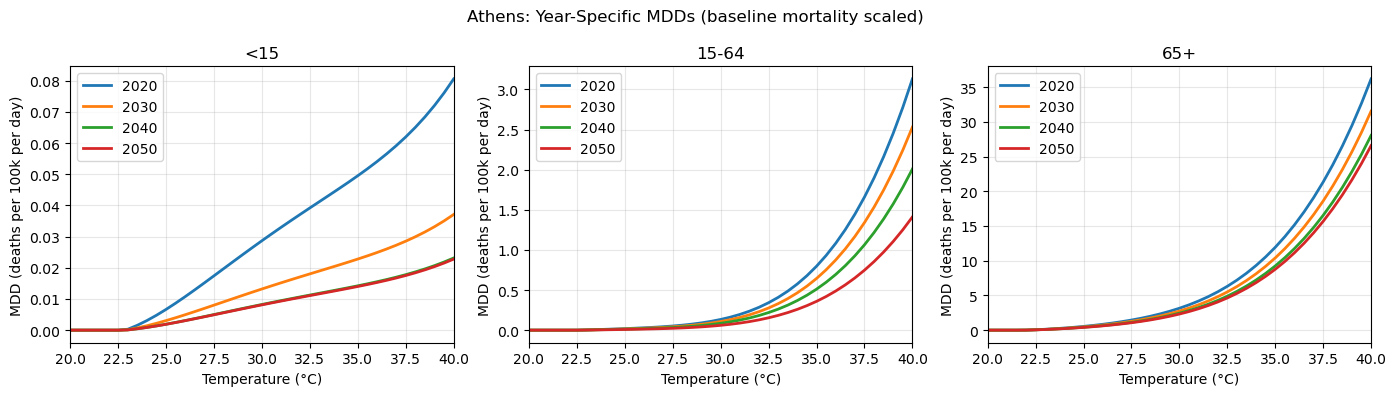

In [31]:
# Visualise how baseline-mortality scaling changes the mdd level by year.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, age_lbl in enumerate(["<15", "15-64", "65+"]):
    ax = axes[i]
    
    for year in IF_YEARS:
        mdd = age_ifs_by_year[year][age_lbl].mdd
        ax.plot(T_arr, mdd * 1e5, label=f"{year}", linewidth=2)
    
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("MDD (deaths per 100k per day)")
    ax.set_title(f"{age_lbl}")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim(20, 40)

plt.suptitle(f"{CITY}: Year-Specific MDDs (baseline mortality scaled)", fontsize=12)
plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_mdd_by_year.png", dpi=150)
plt.show()

In [32]:
daily_df = pd.DataFrame({"date": dates, "temp_degC": citymean_daily})
daily_df["year"] = daily_df["date"].dt.year

print("City-mean daily max by year:")
print(daily_df.groupby("year")["temp_degC"].max())

print("\nCity-mean days above 20°C by year:")
print((daily_df["temp_degC"] > 20).groupby(daily_df["year"]).sum())

print("\nCity-mean days above 22°C by year:")
print((daily_df["temp_degC"] > 22).groupby(daily_df["year"]).sum())

City-mean daily max by year:
year
2020    29.666270
2030    30.205367
2040    30.287703
2050    30.580186
Name: temp_degC, dtype: float64

City-mean days above 20°C by year:
year
2020    157
2030    168
2040    168
2050    173
Name: temp_degC, dtype: int64

City-mean days above 22°C by year:
year
2020    124
2030    128
2040    128
2050    133
Name: temp_degC, dtype: int64


In [33]:
for y in [2020, 2030, 2040, 2050]:
    mask = pd.to_datetime(H.date.astype("datetime64[ns]")).year == y
    H_y = H.intensity[mask, :]
    
    max_pixel_T = float(H_y.max())
    n_hot_pixel_days_20 = int((H_y > 20).sum())
    n_hot_pixel_days_22 = int((H_y > 22).sum())
    
    print(
        f"{y}: max pixel T = {max_pixel_T:.2f}°C | "
        f"pixel-days >20°C = {n_hot_pixel_days_20} | "
        f"pixel-days >22°C = {n_hot_pixel_days_22}"
    )

2020: max pixel T = 32.45°C | pixel-days >20°C = 9537976 | pixel-days >22°C = 7906629
2030: max pixel T = 32.99°C | pixel-days >20°C = 9867516 | pixel-days >22°C = 8298619
2040: max pixel T = 33.07°C | pixel-days >20°C = 9906480 | pixel-days >22°C = 8357672
2050: max pixel T = 33.36°C | pixel-days >20°C = 10091652 | pixel-days >22°C = 8624827


## Outputs written for downstream notebooks

This export block writes the main polynomial IF bundles by year, a legacy frozen reference-year bundle, the baseline-mortality scaling table, and the annual heat-death diagnostics. It also saves a legacy power-law IF export for functional-form comparison and uncertainty workflows, while keeping the polynomial family as the main specification used in the current notebooks.


In [34]:
print("CITY =", CITY)
print("SLUG =", SLUG)
print("INT  =", INT)
print("OUT  =", OUT)

CITY = Athens
SLUG = athens
INT  = /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim
OUT  = /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens


In [35]:
# Save the IF bundles and annual heat-mortality diagnostics used downstream.
from pathlib import Path
import json
import numpy as np

print("Saving with:")
print("CITY =", CITY)
print("SLUG =", SLUG)
print("INT  =", INT)

# Ensure the interim output folder exists.
Path(INT).mkdir(parents=True, exist_ok=True)

freeze_dict_by_year = {}
for year in IF_YEARS:
    freeze_dict_by_year[year] = {}
    for age_lbl, f in age_ifs_by_year[year].items():
        freeze_dict_by_year[year][age_lbl] = {
            "id": int(f.id),
            "name": f.name,
            "intensity": np.asarray(f.intensity, float).tolist(),
            "mdd": np.asarray(f.mdd, float).tolist(),
        }

output = {
    "reference_year": MDD_REF_YEAR,
    "years": IF_YEARS,
    "scaling_source": "Wittgenstein ASSR baseline mortality",
    "ifs_by_year": freeze_dict_by_year,
}

freeze_path = Path(INT) / f"if_curves_by_year_{SLUG}.json"
with open(freeze_path, "w") as fh:
    json.dump(output, fh, indent=2)
print(f"✓ Saved year-specific IFs to: {freeze_path}")

legacy_path = Path(INT) / f"if_curves_frozen_{SLUG}.json"
with open(legacy_path, "w") as fh:
    json.dump(freeze_dict_by_year[MDD_REF_YEAR], fh, indent=2)
print(f"✓ Saved legacy IFs to: {legacy_path}")

sf_path = Path(INT) / f"baseline_heat_scaling_{SLUG}.csv"
scale_factors.to_csv(sf_path)
print(f"✓ Saved scaling factors to: {sf_path}")

manual_raw_path = Path(INT) / f"annual_heat_deaths_manual_{SLUG}.csv"
annual_by_age.to_csv(manual_raw_path)
print(f"✓ Saved manual deaths to: {manual_raw_path}")

generic_raw_path = Path(INT) / f"annual_heat_deaths_generic_{SLUG}.csv"
heat_deaths_generic.index = heat_deaths_generic.index.astype(int)
heat_deaths_generic.index.name = "year"
heat_deaths_generic.to_csv(generic_raw_path)
print(f"✓ Saved generic CLIMADA deaths to: {generic_raw_path}")

# Legacy power-law IF export kept for functional-form comparison and uncertainty workflows.
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet
from climada.engine import ImpactCalc
from climada.entity.exposures import Exposures

per100k = 100_000.0

# Keep the fixed January 2026 power-law calibration unchanged for traceability.
elderly_d_pw, _, _ = heat_tail_power(T_grid, T_ref, d1=3.5, T1=30.0, d2=12.0, T2=35.0)
adult_d_pw, _, _   = heat_tail_power(T_grid, T_ref, d1=0.15, T1=30.0, d2=0.80, T2=35.0)
young_d_pw, _, _   = heat_tail_power(T_grid, T_ref, d1=0.03, T1=30.0, d2=0.05, T2=35.0)

base_mdd_powerlaw = {
    "<15":   np.clip(np.asarray(young_d_pw, float)   / per100k, 0, 1),
    "15-64": np.clip(np.asarray(adult_d_pw, float)   / per100k, 0, 1),
    "65+":   np.clip(np.asarray(elderly_d_pw, float) / per100k, 0, 1),
}

age_ifs_by_year_powerlaw = {}
age_to_if_id_local = {"<15": 1, "15-64": 2, "65+": 3}
for year in IF_YEARS:
    age_ifs_by_year_powerlaw[year] = {}
    for age_lbl, base_arr in base_mdd_powerlaw.items():
        scale = float(scale_factors.loc[year, age_lbl]) if year in scale_factors.index else 1.0
        scaled_mdd = np.clip(base_arr * scale, 0, 1)
        age_ifs_by_year_powerlaw[year][age_lbl] = ImpactFunc(
            haz_type="T2M",
            id=age_to_if_id_local[age_lbl],
            intensity=T_arr,
            mdd=scaled_mdd,
            paa=np.ones_like(T_arr),
            name=f"{age_lbl}_{year}_powerlaw",
        )

freeze_dict_by_year_pw = {}
for year in IF_YEARS:
    freeze_dict_by_year_pw[year] = {}
    for age_lbl, f in age_ifs_by_year_powerlaw[year].items():
        freeze_dict_by_year_pw[year][age_lbl] = {
            "id": int(f.id),
            "name": f.name,
            "intensity": np.asarray(f.intensity, float).tolist(),
            "mdd": np.asarray(f.mdd, float).tolist(),
        }

output_pw = {
    "reference_year": MDD_REF_YEAR,
    "years": IF_YEARS,
    "scaling_source": "Wittgenstein ASSR baseline mortality",
    "functional_form": "powerlaw_january2026_fixed_anchors",
    "powerlaw_parameters_per100k": {
        "<15": {"d1": 0.03, "T1": 30.0, "d2": 0.05, "T2": 35.0},
        "15-64": {"d1": 0.15, "T1": 30.0, "d2": 0.80, "T2": 35.0},
        "65+": {"d1": 3.5, "T1": 30.0, "d2": 12.0, "T2": 35.0},
    },
    "ifs_by_year": freeze_dict_by_year_pw,
}

freeze_path_pw = Path(INT) / f"if_curves_by_year_{SLUG}_powerlaw.json"
with open(freeze_path_pw, "w") as fh:
    json.dump(output_pw, fh, indent=2)
print(f"✓ Saved legacy-style power-law IFs to: {freeze_path_pw}")

legacy_path_pw = Path(INT) / f"if_curves_frozen_{SLUG}_powerlaw.json"
with open(legacy_path_pw, "w") as fh:
    json.dump(freeze_dict_by_year_pw[MDD_REF_YEAR], fh, indent=2)
print(f"✓ Saved legacy-style power-law reference IFs to: {legacy_path_pw}")

# Optional traceability output: annual deaths under this legacy power-law family.
AGES_LOCAL = ["15-64", "65+", "<15"]
powerlaw_annual = {age: {} for age in AGES_LOCAL}

for year in IF_YEARS:
    H_y = hazard_for_year(H, year)
    ifs_y = ImpactFuncSet(list(age_ifs_by_year_powerlaw[year].values()))
    ifs_y.check()
    exp_src = exposures_by_year[year]

    for age_lbl in AGES_LOCAL:
        gdf_age = exp_src.gdf.loc[exp_src.gdf["age_group"] == age_lbl].copy()
        gdf_age["impf_T2M"] = age_to_if_id_local[age_lbl]

        exp_age = Exposures()
        exp_age.set_gdf(gdf_age)
        exp_age.value_unit = getattr(exp_src, "value_unit", "people")
        exp_age.ref_year = getattr(exp_src, "ref_year", year)

        imp = ImpactCalc(exp_age, ifs_y, H_y).impact(save_mat=False)
        powerlaw_annual[age_lbl][year] = float(np.sum(imp.at_event))

heat_deaths_powerlaw = (
    pd.DataFrame({age: pd.Series(vals) for age, vals in powerlaw_annual.items()})
    .sort_index()
)[AGES_LOCAL]

powerlaw_raw_path = Path(INT) / f"annual_heat_deaths_generic_{SLUG}_powerlaw.csv"
heat_deaths_powerlaw.index = heat_deaths_powerlaw.index.astype(int)
heat_deaths_powerlaw.index.name = "year"
heat_deaths_powerlaw.to_csv(powerlaw_raw_path)
print(f"✓ Saved legacy-style power-law annual deaths to: {powerlaw_raw_path}")



Saving with:
CITY = Athens
SLUG = athens
INT  = /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim
✓ Saved year-specific IFs to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/if_curves_by_year_athens.json
✓ Saved legacy IFs to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/if_curves_frozen_athens.json
✓ Saved scaling factors to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/baseline_heat_scaling_athens.csv
✓ Saved manual deaths to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/annual_heat_deaths_manual_athens.csv
✓ Saved generic CLIMADA deaths to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/annual_heat_deaths_generic_athens.csv
✓ Saved legacy-style power-law IFs to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/interim/if_curves_by_yea

## Sensitivity analysis

Because the IFs are calibrated by eye from a published figure, the notebook treats uncertainty transparently rather than hiding it inside a single preferred curve. The blocks below examine several distinct questions:

1. Does the hazard actually reach the temperature range where the IF becomes active?
2. How much do results move if the Burke-derived anchor levels are uniformly scaled up or down?
3. Does the choice between a polynomial and a power-law family matter over the empirical temperature range reached by the hazard?
4. How sensitive are results to the reference / onset temperature?
5. How do simple mortality-displacement reporting assumptions change gross annual totals?
6. How can the same IF be written in an RR-style representation?
7. What is the compact summary of these sensitivity checks?

These diagnostics complement the more formal uncertainty treatment implemented later in `NB09`.


In [36]:
# Sensitivity-analysis helpers and shared plotting / output utilities.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from pathlib import Path

from climada.engine import ImpactCalc
from climada.entity.exposures import Exposures
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet

AGE_ORDER = ["<15", "15-64", "65+"]
AGE_TO_IF_ID = {"<15": 1, "15-64": 2, "65+": 3}
WARM_MONTHS = [5, 6, 7, 8, 9]

fig_dir = OUT / "figures"
table_dir = OUT / "tables"
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

def safe_pct_change(new, base, eps=1e-12):
    """Return % change unless the baseline is effectively zero."""
    if np.abs(base) <= eps:
        return np.nan
    return 100.0 * (new - base) / base

def ensure_age_order(df):
    """Ensure consistent age-column order and add total."""
    out = df.copy()
    for age in AGE_ORDER:
        if age not in out.columns:
            out[age] = 0.0
    out = out[AGE_ORDER].sort_index()
    out["total"] = out.sum(axis=1)
    return out

baseline_unscaled = ensure_age_order(heat_deaths_generic)

baseline_scaled = None
if "heat_deaths_generic_scaled" in globals():
    baseline_scaled = ensure_age_order(heat_deaths_generic_scaled)

def scale_ref_points(ref_points, scale_factor):
    """Uniformly scale mortality values in reference points."""
    return [(float(T), float(d) * float(scale_factor)) for T, d in ref_points]

def last_two_positive_points(ref_points):
    """Pick the last two strictly positive anchor points for power-law fitting."""
    pts = [(T, d) for T, d in ref_points if d > 0]
    if len(pts) < 2:
        raise ValueError("Need at least two positive reference points for power-law calibration.")
    return pts[-2], pts[-1]

def build_mdd_curves(
    T_grid,
    T_ref_local,
    functional_form="polynomial",
    point_scale_by_age=None,
):
    """
    Build age-specific mdd(T) curves.

    Returns
    -------
    mdd_curves : dict
        dict[age] -> array of mdd(T)
    meta : dict
        fitting metadata
    """
    if point_scale_by_age is None:
        point_scale_by_age = {age: 1.0 for age in AGE_ORDER}

    scaled_points = {
        "<15":   scale_ref_points(young_ref_points,   point_scale_by_age["<15"]),
        "15-64": scale_ref_points(adult_ref_points,   point_scale_by_age["15-64"]),
        "65+":   scale_ref_points(elderly_ref_points, point_scale_by_age["65+"]),
    }

    mdd_curves = {}
    meta = {}

    for age, ref_points in scaled_points.items():
        if functional_form == "polynomial":
            d_per100k, coeffs = heat_tail_polynomial(
                T_grid, T_ref_local, ref_points, degree=4
            )
            meta[age] = {"coeffs": np.asarray(coeffs, float)}
        elif functional_form == "powerlaw":
            (T1, d1), (T2, d2) = last_two_positive_points(ref_points)
            d_per100k, beta, p = heat_tail_power(
                T_grid, T_ref_local, d1=d1, T1=T1, d2=d2, T2=T2
            )
            meta[age] = {
                "beta": float(beta),
                "p": float(p),
                "anchor_1": (T1, d1),
                "anchor_2": (T2, d2),
            }
        else:
            raise ValueError("functional_form must be 'polynomial' or 'powerlaw'.")

        mdd_curves[age] = np.clip(np.asarray(d_per100k, float) / 100_000.0, 0, 1)

    return mdd_curves, meta

def curves_to_ifset(mdd_curves, T_grid, name_suffix=""):
    """Convert age-specific mdd curves to a CLIMADA ImpactFuncSet."""
    T_arr_local = np.asarray(T_grid, float)
    if_list = []

    for age in AGE_ORDER:
        if_list.append(
            ImpactFunc(
                haz_type="T2M",
                id=AGE_TO_IF_ID[age],
                intensity=T_arr_local,
                mdd=np.asarray(mdd_curves[age], float),
                paa=np.ones_like(T_arr_local),
                name=f"{age}{name_suffix}",
            )
        )

    ifs = ImpactFuncSet(if_list)
    ifs.check()
    return ifs

def run_impact_for_year(year, ifs_obj):
    """Run CLIMADA for one year using one ImpactFuncSet."""
    exp_src = exposures_by_year[year]
    H_y = hazard_for_year(H, year)

    out = {}
    for age_lbl in AGE_ORDER:
        gdf_age = exp_src.gdf.loc[exp_src.gdf["age_group"] == age_lbl].copy()
        gdf_age["impf_T2M"] = AGE_TO_IF_ID[age_lbl]

        exp_age = Exposures()
        exp_age.set_gdf(gdf_age)
        exp_age.value_unit = getattr(exp_src, "value_unit", "people")
        exp_age.ref_year = getattr(exp_src, "ref_year", year)

        imp = ImpactCalc(exp_age, ifs_obj, H_y).impact(save_mat=False)
        out[age_lbl] = float(np.sum(imp.at_event))

    return out

def run_impact_all_years(ifs_input, years=YEARS):
    """
    Run CLIMADA across all years.

    ifs_input can be:
    - one ImpactFuncSet used for all years
    - a dict: year -> ImpactFuncSet
    """
    rows = []
    for year in years:
        ifs_y = ifs_input[year] if isinstance(ifs_input, dict) else ifs_input
        res = run_impact_for_year(year, ifs_y)
        res["year"] = year
        rows.append(res)

    df = pd.DataFrame(rows).set_index("year")
    return ensure_age_order(df)

print("Sensitivity setup initialized.")
print(f"City: {CITY} | SLUG: {SLUG}")
display(baseline_unscaled)

if baseline_scaled is not None:
    display(baseline_scaled)

Sensitivity setup initialized.
City: Athens | SLUG: athens


,<15,15-64,65+,total
year,,,,
2020,10.211411,214.063384,1608.189834,1832.464629
2030,8.678390,228.826361,2041.818864,2279.323615
2040,8.464938,215.879889,2470.703909,2695.048737
2050,9.280169,217.591780,3007.649985,3234.521935


,<15,15-64,65+,total
2020,10.211411,214.063384,1608.189834,1832.464629
2030,3.996140,184.918859,1780.197897,1969.112896
2040,2.431145,138.436102,1915.014531,2055.881779
2050,2.624520,98.032313,2209.570749,2310.227582


### 1. Empirical temperature support

Before varying the IF parameters, we check whether the hazard actually reaches the temperatures where the curves become active. In cooler cities, this empirical support question can matter as much as the exact tail shape because results may be driven by the onset region rather than the most extreme temperatures.


Empirical temperature support:


,citymean_max,warmseason_max,pixel_max,city_days_gt_18,warm_days_ge_18,pixel_days_gt_18,city_days_gt_19,warm_days_ge_19,pixel_days_gt_19,city_days_gt_20,warm_days_ge_20,pixel_days_gt_20,city_days_gt_21,warm_days_ge_21,pixel_days_gt_21,city_days_gt_22,warm_days_ge_22,pixel_days_gt_22
year,,,,,,,,,,,,,,,,,,
2020,29.666270,29.666270,32.446999,177,153,11067258,174,153,10226402,157,145,9537976,137,136,8789339,124,124,7906629
2030,30.205367,30.205367,32.986095,179,153,11468916,176,153,10606862,168,151,9867516,147,138,9149053,128,128,8298619
2040,30.287703,30.287703,33.068432,180,153,11545236,176,153,10708988,168,151,9906480,148,138,9191476,128,128,8357672
2050,30.580186,30.580186,33.360916,181,153,11760314,176,153,10915721,173,152,10091652,151,139,9374998,133,132,8624827


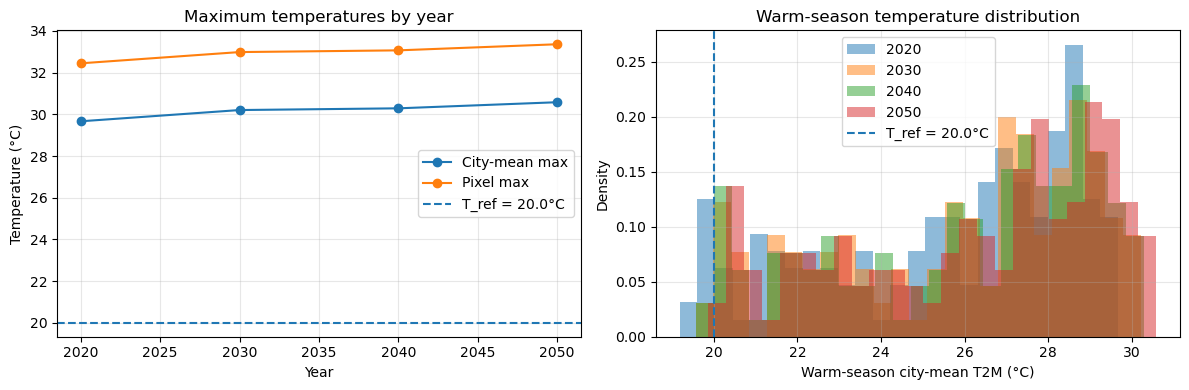

In [37]:
# 1. EMPIRICAL TEMPERATURE SUPPORT

# Rebuild daily_df if needed
if "daily_df" not in globals() or "citymean_degC" not in daily_df.columns:
    num = H.intensity.multiply(H.fraction).sum(axis=1)
    den = H.fraction.sum(axis=1)
    citymean_daily = (num / den).A1

    daily_df = pd.DataFrame({
        "date": pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]"))),
        "citymean_degC": citymean_daily,
    })
    daily_df["year"] = daily_df["date"].dt.year
    daily_df["month"] = daily_df["date"].dt.month
    daily_df["doy"] = daily_df["date"].dt.dayofyear

warm_df = daily_df[daily_df["month"].isin(WARM_MONTHS)].copy()

support_thresholds = [18, 19, 20, 21, 22]
support_rows = []

for year in YEARS:
    city_series = daily_df.loc[daily_df["year"] == year, "citymean_degC"]
    warm_series = warm_df.loc[warm_df["year"] == year, "citymean_degC"]

    mask = pd.to_datetime(H.date.astype("datetime64[ns]")).year == year
    H_y = H.intensity[mask, :]

    row = {
        "year": year,
        "citymean_max": float(city_series.max()),
        "warmseason_max": float(warm_series.max()),
        "pixel_max": float(H_y.max()),
    }

    for thr in support_thresholds:
        row[f"city_days_gt_{thr}"] = int((city_series > thr).sum())
        row[f"warm_days_ge_{thr}"] = int((warm_series >= thr).sum())
        row[f"pixel_days_gt_{thr}"] = int((H_y > thr).sum())

    support_rows.append(row)

support_df = pd.DataFrame(support_rows).set_index("year")

print("Empirical temperature support:")
display(support_df)

support_df.to_csv(table_dir / f"{SLUG}_sensitivity_temperature_support.csv")

# quick diagnostic figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: maximum temperatures by year
ax = axes[0]
ax.plot(support_df.index, support_df["citymean_max"], marker="o", label="City-mean max")
ax.plot(support_df.index, support_df["pixel_max"], marker="o", label="Pixel max")
ax.axhline(float(T_ref), linestyle="--", label=f"T_ref = {T_ref:.1f}°C")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Maximum temperatures by year")
ax.grid(True, alpha=0.3)
ax.legend()

# Right: warm-season distribution
ax = axes[1]
for year in YEARS:
    vals = warm_df.loc[warm_df["year"] == year, "citymean_degC"]
    ax.hist(vals, bins=25, alpha=0.5, density=True, label=str(year))
ax.axvline(float(T_ref), linestyle="--", label=f"T_ref = {T_ref:.1f}°C")
ax.set_xlabel("Warm-season city-mean T2M (°C)")
ax.set_ylabel("Density")
ax.set_title("Warm-season temperature distribution")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(fig_dir / f"{SLUG}_sensitivity_temperature_support.png", dpi=150, bbox_inches="tight")
plt.show()

### 2. Anchor-point scale sensitivity

This block uniformly scales the Burke-derived anchor values up and down. It tests sensitivity to the overall **level** of the IFs while keeping the same qualitative age pattern and the same reference temperature.


Anchor-point scale sensitivity:


,year,<15,15-64,65+,total,scale,baseline_total,abs_diff_vs_baseline,pct_diff_vs_baseline
0,2020,8.169129,171.250707,1286.551867,1465.971703,0.8,1832.464629,-366.492926,-20.0
1,2030,6.942712,183.061089,1633.455091,1823.458892,0.8,2279.323615,-455.864723,-20.0
2,2040,6.771950,172.703911,1976.563128,2156.038989,0.8,2695.048737,-539.009747,-20.0
3,2050,7.424136,174.073424,2406.119988,2587.617548,0.8,3234.521935,-646.904387,-20.0
4,2020,9.190270,192.657045,1447.370851,1649.218166,0.9,1832.464629,-183.246463,-10.0
5,2030,7.810551,205.943725,1837.636978,2051.391254,0.9,2279.323615,-227.932362,-10.0
6,2040,7.618444,194.291900,2223.633519,2425.543863,0.9,2695.048737,-269.504874,-10.0
7,2050,8.352153,195.832602,2706.884986,2911.069741,0.9,3234.521935,-323.452193,-10.0
8,2020,10.211411,214.063384,1608.189834,1832.464629,1.0,1832.464629,0.000000,0.0
9,2030,8.678390,228.826361,2041.818864,2279.323615,1.0,2279.323615,0.000000,0.0


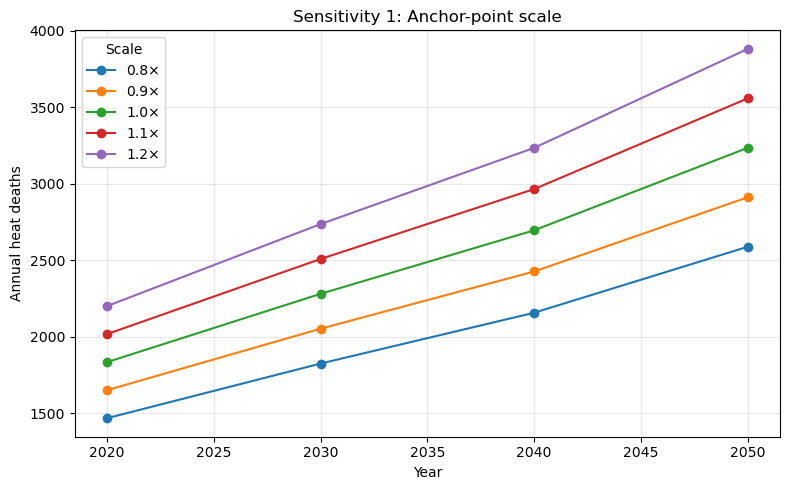

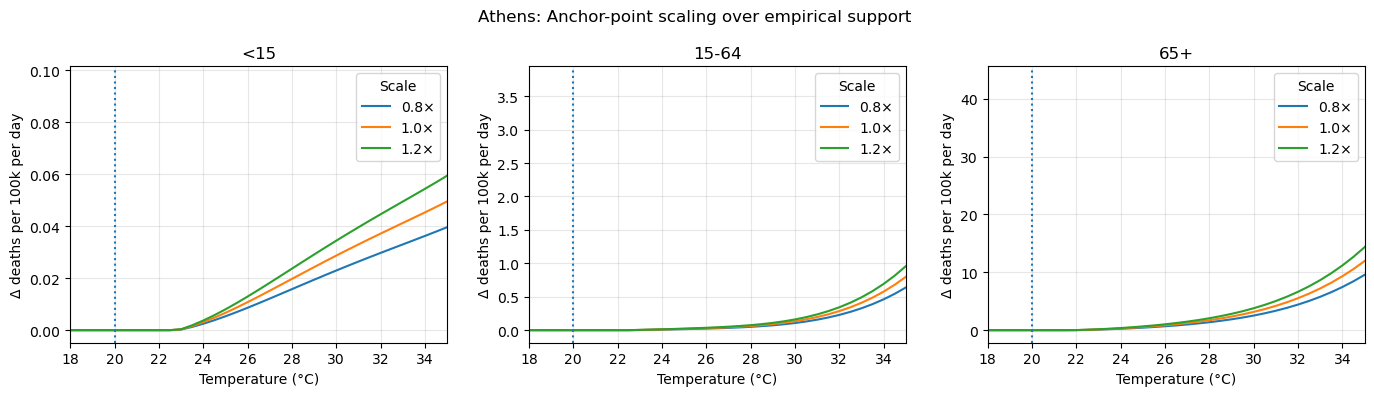

In [38]:
# 2. ANCHOR-POINT SCALE SENSITIVITY

# Uniformly scale all Burke anchor-point y-values up/down
# This is a simple uncertainty exercise around the level of the IF.
param_scales = [0.8, 0.9, 1.0, 1.1, 1.2]

param_frames = []
param_curve_store = {}

for scale in param_scales:
    mdd_curves_scaled, meta_scaled = build_mdd_curves(
        T_grid=T_grid,
        T_ref_local=T_ref,
        functional_form="polynomial",
        point_scale_by_age={age: scale for age in AGE_ORDER},
    )

    ifs_scaled = curves_to_ifset(
        mdd_curves_scaled,
        T_grid,
        name_suffix=f"_scale_{scale:.1f}"
    )

    df_scaled = run_impact_all_years(ifs_scaled)
    df_scaled["scale"] = scale
    param_frames.append(df_scaled.reset_index())

    param_curve_store[scale] = {
        "mdd_curves": mdd_curves_scaled,
        "meta": meta_scaled,
    }

param_sensitivity_df = pd.concat(param_frames, ignore_index=True)

# compare each scale to the 1.0x baseline
param_baseline_lookup = (
    param_sensitivity_df.loc[param_sensitivity_df["scale"] == 1.0, ["year", "total"]]
    .rename(columns={"total": "baseline_total"})
)

param_sensitivity_df = param_sensitivity_df.merge(
    param_baseline_lookup,
    on="year",
    how="left"
)

param_sensitivity_df["abs_diff_vs_baseline"] = (
    param_sensitivity_df["total"] - param_sensitivity_df["baseline_total"]
)

param_sensitivity_df["pct_diff_vs_baseline"] = param_sensitivity_df.apply(
    lambda r: safe_pct_change(r["total"], r["baseline_total"]),
    axis=1
)

print("Anchor-point scale sensitivity:")
display(param_sensitivity_df)

param_sensitivity_df.to_csv(
    table_dir / f"{SLUG}_sensitivity_anchor_scale.csv",
    index=False
)

# Plots

# Plot totals by year
fig, ax = plt.subplots(figsize=(8, 5))
for scale in param_scales:
    sub = param_sensitivity_df[param_sensitivity_df["scale"] == scale].sort_values("year")
    ax.plot(sub["year"], sub["total"], marker="o", label=f"{scale:.1f}×")
ax.set_xlabel("Year")
ax.set_ylabel("Annual heat deaths")
ax.set_title("Sensitivity 1: Anchor-point scale")
ax.grid(True, alpha=0.3)
ax.legend(title="Scale")
plt.tight_layout()
plt.savefig(
    fig_dir / f"{SLUG}_sensitivity_anchor_scale_totals.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# Plot curves over the empirical support range
support_xmin = max(
    0,
    float(np.floor(min(warm_df["citymean_degC"].min(), T_ref) - 1))
)
support_xmax = min(
    float(np.max(T_grid)),
    float(np.ceil(max(float(H.intensity.max()), warm_df["citymean_degC"].max()) + 1))
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for i, age in enumerate(AGE_ORDER):
    ax = axes[i]
    for scale in [0.8, 1.0, 1.2]:
        ax.plot(
            T_grid,
            param_curve_store[scale]["mdd_curves"][age] * 1e5,
            label=f"{scale:.1f}×"
        )
    ax.axvline(float(T_ref), linestyle=":")
    ax.set_xlim(support_xmin, support_xmax)
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Δ deaths per 100k per day")
    ax.set_title(age)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Scale")

plt.suptitle(f"{CITY}: Anchor-point scaling over empirical support")
plt.tight_layout()
plt.savefig(
    fig_dir / f"{SLUG}_sensitivity_anchor_scale_curves.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

### 3. Functional-form sensitivity

The polynomial curve is the main specification in the current notebooks. Here it is compared with a power-law curve built from the same Burke-style anchor logic so we can see whether the chosen functional family matters over the temperature range actually reached by the hazard.


Functional-form sensitivity:


,functional_form,year,<15,15-64,65+,total,poly_total,abs_diff_vs_poly,pct_diff_vs_poly
0,polynomial,2020,10.211411,214.063384,1608.189834,1832.464629,1832.464629,0.000000,0.000000
1,polynomial,2030,8.678390,228.826361,2041.818864,2279.323615,2279.323615,0.000000,0.000000
2,polynomial,2040,8.464938,215.879889,2470.703909,2695.048737,2695.048737,0.000000,0.000000
3,polynomial,2050,9.280169,217.591780,3007.649985,3234.521935,3234.521935,0.000000,0.000000
4,powerlaw,2020,10.466952,159.692210,1195.996675,1366.155837,1832.464629,-466.308792,-25.447083
5,powerlaw,2030,8.871005,177.193001,1562.415719,1748.479725,2279.323615,-530.843890,-23.289536
6,powerlaw,2040,8.627956,169.099078,1908.529470,2086.256504,2695.048737,-608.792233,-22.589285
7,powerlaw,2050,9.433091,174.913893,2373.306202,2557.653186,3234.521935,-676.868749,-20.926392


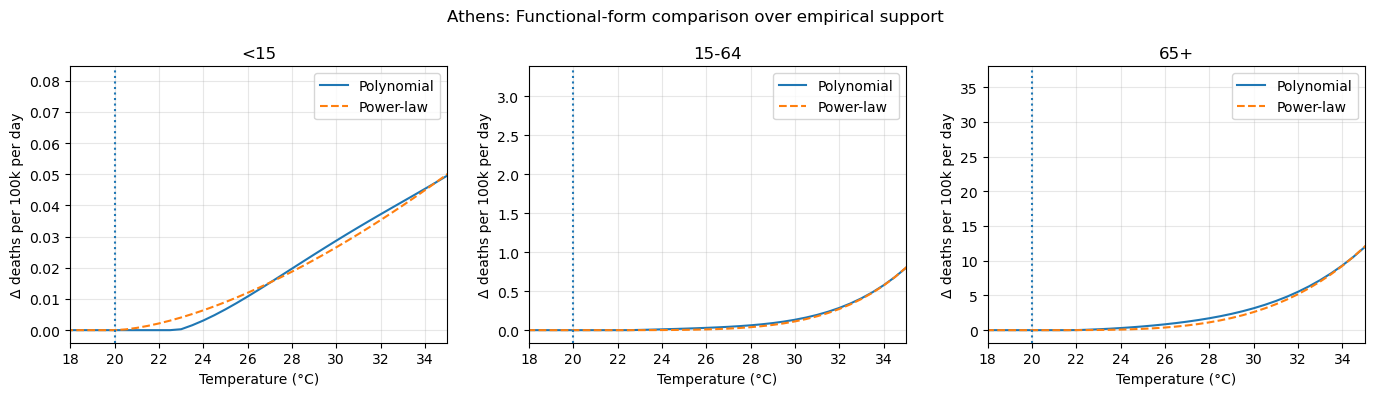

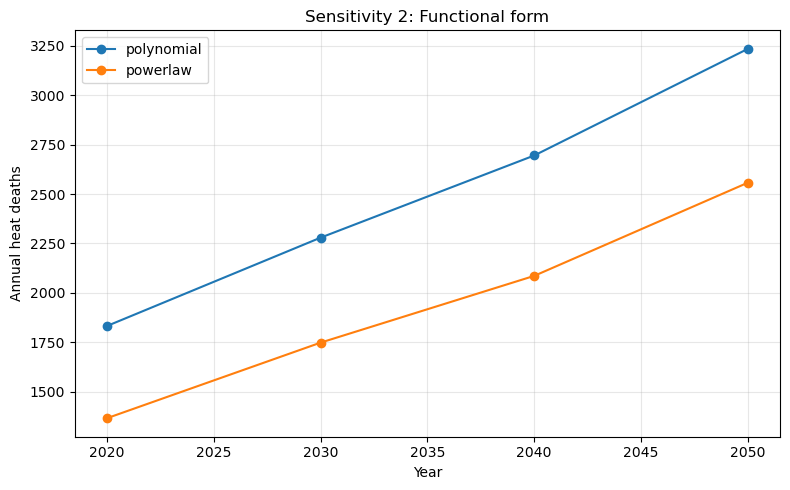

In [39]:
# 3. FUNCTIONAL-FORM SENSITIVITY

functional_form_results = {}
curve_store = {}

for form in ["polynomial", "powerlaw"]:
    mdd_curves_form, meta_form = build_mdd_curves(
        T_grid=T_grid,
        T_ref_local=T_ref,
        functional_form=form,
        point_scale_by_age={age: 1.0 for age in AGE_ORDER},
    )
    ifs_form = curves_to_ifset(mdd_curves_form, T_grid, name_suffix=f"_{form}")
    functional_form_results[form] = run_impact_all_years(ifs_form)
    curve_store[form] = {"mdd_curves": mdd_curves_form, "meta": meta_form}

functional_form_df = (
    pd.concat(functional_form_results, names=["functional_form", "year"])
    .reset_index()
)

poly_lookup = (
    functional_form_df.loc[functional_form_df["functional_form"] == "polynomial", ["year", "total"]]
    .rename(columns={"total": "poly_total"})
)

functional_form_df = functional_form_df.merge(poly_lookup, on="year", how="left")
functional_form_df["abs_diff_vs_poly"] = functional_form_df["total"] - functional_form_df["poly_total"]
functional_form_df["pct_diff_vs_poly"] = functional_form_df.apply(
    lambda r: safe_pct_change(r["total"], r["poly_total"]), axis=1
)

print("Functional-form sensitivity:")
display(functional_form_df)

functional_form_df.to_csv(table_dir / f"{SLUG}_sensitivity_functional_form.csv", index=False)

# Plot only over the empirical support range + small buffer
support_xmin = max(0, float(np.floor(min(warm_df["citymean_degC"].min(), T_ref) - 1)))
support_xmax = min(float(np.max(T_grid)), float(np.ceil(max(float(H.intensity.max()), warm_df["citymean_degC"].max()) + 1)))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for i, age in enumerate(AGE_ORDER):
    ax = axes[i]
    ax.plot(T_grid, curve_store["polynomial"]["mdd_curves"][age] * 1e5, label="Polynomial")
    ax.plot(T_grid, curve_store["powerlaw"]["mdd_curves"][age] * 1e5, linestyle="--", label="Power-law")
    ax.axvline(float(T_ref), linestyle=":")
    ax.set_xlim(support_xmin, support_xmax)
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Δ deaths per 100k per day")
    ax.set_title(age)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle(f"{CITY}: Functional-form comparison over empirical support")
plt.tight_layout()
plt.savefig(fig_dir / f"{SLUG}_sensitivity_functional_form_curves.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for form in ["polynomial", "powerlaw"]:
    sub = functional_form_df[functional_form_df["functional_form"] == form].sort_values("year")
    ax.plot(sub["year"], sub["total"], marker="o", label=form)
ax.set_xlabel("Year")
ax.set_ylabel("Annual heat deaths")
ax.set_title("Sensitivity 2: Functional form")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir / f"{SLUG}_sensitivity_functional_form_totals.png", dpi=150, bbox_inches="tight")
plt.show()

### 4. Reference / onset temperature sensitivity

The code next varies `T_ref` using warm-season percentiles from the baseline year, together with the default input value. This isolates sensitivity to where heat-related excess mortality is assumed to start.


Reference-temperature candidates:


,label,T_ref_test
0,baseline_input,20.0
1,p85_2020,28.6
2,p90_2020,28.8
3,p95_2020,29.2


Reference / onset temperature sensitivity:


,year,<15,15-64,65+,total,label,T_ref_test,baseline_total,abs_diff_vs_baseline,pct_diff_vs_baseline
0,2020,10.211411,214.063384,1608.189834,1832.464629,baseline_input,20.0,1832.464629,0.000000,0.000000
1,2030,8.678390,228.826361,2041.818864,2279.323615,baseline_input,20.0,2279.323615,0.000000,0.000000
2,2040,8.464938,215.879889,2470.703909,2695.048737,baseline_input,20.0,2695.048737,0.000000,0.000000
3,2050,9.280169,217.591780,3007.649985,3234.521935,baseline_input,20.0,3234.521935,0.000000,0.000000
4,2020,2.353468,86.860755,544.784157,633.998381,p85_2020,28.6,1832.464629,-1198.466248,-65.401876
5,2030,2.452605,109.749414,828.189194,940.391213,p85_2020,28.6,2279.323615,-1338.932402,-58.742532
6,2040,2.534374,108.169593,1052.497353,1163.201319,p85_2020,28.6,2695.048737,-1531.847417,-56.839322
7,2050,3.201533,121.421113,1443.921585,1568.544230,p85_2020,28.6,3234.521935,-1665.977705,-51.506150
8,2020,2.056464,79.145566,489.076583,570.278612,p90_2020,28.8,1832.464629,-1262.186017,-68.879148
9,2030,2.183233,101.741533,757.414743,861.339509,p90_2020,28.8,2279.323615,-1417.984106,-62.210741


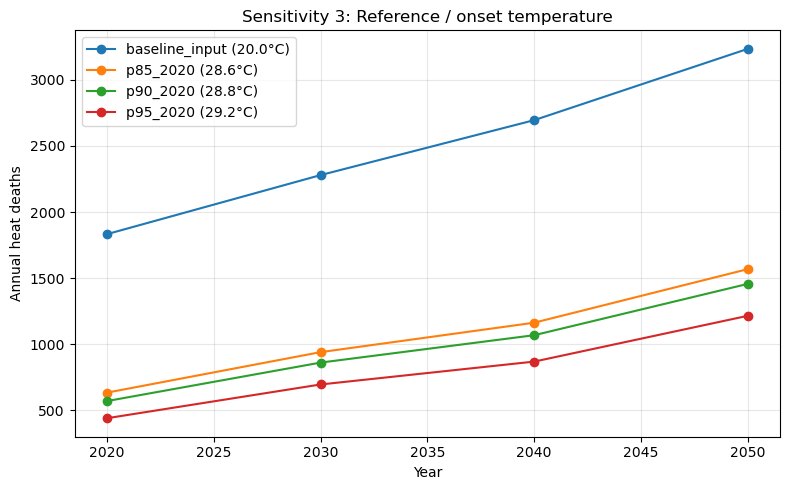

In [40]:
# 4. REFERENCE / ONSET TEMPERATURE SENSITIVITY

baseline_year = int(min(YEARS))
warm_baseline = warm_df.loc[warm_df["year"] == baseline_year, "citymean_degC"].dropna().to_numpy()

tref_candidates_df = pd.DataFrame([
    {"label": f"p85_{baseline_year}", "T_ref_test": round(float(np.percentile(warm_baseline, 85)), 1)},
    {"label": f"p90_{baseline_year}", "T_ref_test": round(float(np.percentile(warm_baseline, 90)), 1)},
    {"label": f"p95_{baseline_year}", "T_ref_test": round(float(np.percentile(warm_baseline, 95)), 1)},
    {"label": "baseline_input",       "T_ref_test": round(float(T_ref), 1)},
])

# Drop duplicated temperatures, but keep first occurrence
tref_candidates_df = (
    tref_candidates_df.drop_duplicates(subset=["T_ref_test"], keep="first")
    .sort_values("T_ref_test")
    .reset_index(drop=True)
)

print("Reference-temperature candidates:")
display(tref_candidates_df)

tref_frames = []

for _, row in tref_candidates_df.iterrows():
    tref_val = float(row["T_ref_test"])
    tref_label = str(row["label"])

    mdd_curves_tmp, _ = build_mdd_curves(
        T_grid=T_grid,
        T_ref_local=tref_val,
        functional_form="polynomial",
        point_scale_by_age={age: 1.0 for age in AGE_ORDER},
    )
    ifs_tmp = curves_to_ifset(mdd_curves_tmp, T_grid, name_suffix=f"_tref_{tref_val:.1f}")
    df_tmp = run_impact_all_years(ifs_tmp)
    df_tmp["label"] = tref_label
    df_tmp["T_ref_test"] = tref_val
    tref_frames.append(df_tmp.reset_index())

tref_sensitivity_df = pd.concat(tref_frames, ignore_index=True)

tref_baseline_lookup = (
    tref_sensitivity_df.loc[tref_sensitivity_df["label"] == "baseline_input", ["year", "total"]]
    .rename(columns={"total": "baseline_total"})
)

tref_sensitivity_df = tref_sensitivity_df.merge(tref_baseline_lookup, on="year", how="left")
tref_sensitivity_df["abs_diff_vs_baseline"] = tref_sensitivity_df["total"] - tref_sensitivity_df["baseline_total"]
tref_sensitivity_df["pct_diff_vs_baseline"] = tref_sensitivity_df.apply(
    lambda r: safe_pct_change(r["total"], r["baseline_total"]), axis=1
)

print("Reference / onset temperature sensitivity:")
display(tref_sensitivity_df)

tref_sensitivity_df.to_csv(table_dir / f"{SLUG}_sensitivity_tref.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
for _, row in tref_candidates_df.iterrows():
    sub = tref_sensitivity_df[tref_sensitivity_df["label"] == row["label"]].sort_values("year")
    ax.plot(sub["year"], sub["total"], marker="o", label=f"{row['label']} ({row['T_ref_test']:.1f}°C)")
ax.set_xlabel("Year")
ax.set_ylabel("Annual heat deaths")
ax.set_title("Sensitivity 3: Reference / onset temperature")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir / f"{SLUG}_sensitivity_tref.png", dpi=150, bbox_inches="tight")
plt.show()

Reference-temperature candidates:


,label,T_ref_test
0,baseline_input,20.0
1,p85_2020,28.6
2,p90_2020,28.8
3,p95_2020,29.2


Reference / onset temperature sensitivity:


,year,<15,15-64,65+,total,label,T_ref_test,baseline_total,abs_diff_vs_baseline,pct_diff_vs_baseline
0,2020,10.211411,214.063384,1608.189834,1832.464629,baseline_input,20.0,1832.464629,0.000000,0.000000
1,2030,8.678390,228.826361,2041.818864,2279.323615,baseline_input,20.0,2279.323615,0.000000,0.000000
2,2040,8.464938,215.879889,2470.703909,2695.048737,baseline_input,20.0,2695.048737,0.000000,0.000000
3,2050,9.280169,217.591780,3007.649985,3234.521935,baseline_input,20.0,3234.521935,0.000000,0.000000
4,2020,2.353468,86.860755,544.784157,633.998381,p85_2020,28.6,1832.464629,-1198.466248,-65.401876
5,2030,2.452605,109.749414,828.189194,940.391213,p85_2020,28.6,2279.323615,-1338.932402,-58.742532
6,2040,2.534374,108.169593,1052.497353,1163.201319,p85_2020,28.6,2695.048737,-1531.847417,-56.839322
7,2050,3.201533,121.421113,1443.921585,1568.544230,p85_2020,28.6,3234.521935,-1665.977705,-51.506150
8,2020,2.056464,79.145566,489.076583,570.278612,p90_2020,28.8,1832.464629,-1262.186017,-68.879148
9,2030,2.183233,101.741533,757.414743,861.339509,p90_2020,28.8,2279.323615,-1417.984106,-62.210741


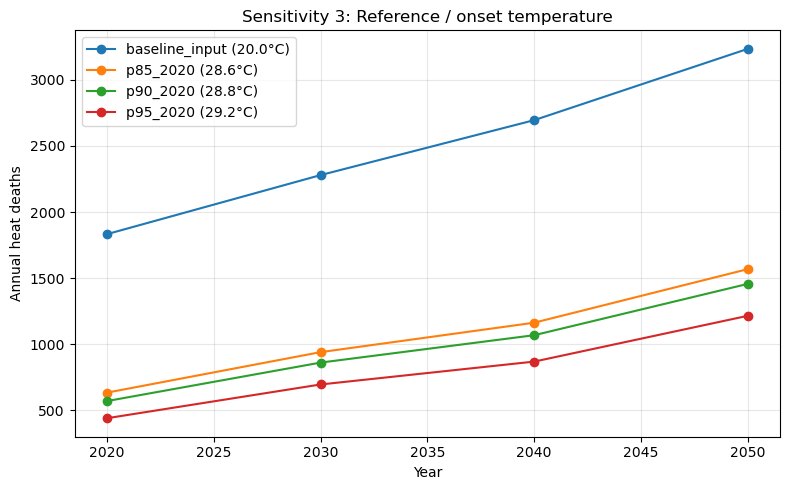

In [41]:
# Re-run of the same reference / onset temperature sensitivity block retained in the current notebook version.

baseline_year = int(min(YEARS))
warm_baseline = warm_df.loc[warm_df["year"] == baseline_year, "citymean_degC"].dropna().to_numpy()

tref_candidates_df = pd.DataFrame([
    {"label": f"p85_{baseline_year}", "T_ref_test": round(float(np.percentile(warm_baseline, 85)), 1)},
    {"label": f"p90_{baseline_year}", "T_ref_test": round(float(np.percentile(warm_baseline, 90)), 1)},
    {"label": f"p95_{baseline_year}", "T_ref_test": round(float(np.percentile(warm_baseline, 95)), 1)},
    {"label": "baseline_input",       "T_ref_test": round(float(T_ref), 1)},
])

# Drop duplicated temperatures, but keep first occurrence
tref_candidates_df = (
    tref_candidates_df.drop_duplicates(subset=["T_ref_test"], keep="first")
    .sort_values("T_ref_test")
    .reset_index(drop=True)
)

print("Reference-temperature candidates:")
display(tref_candidates_df)

tref_frames = []

for _, row in tref_candidates_df.iterrows():
    tref_val = float(row["T_ref_test"])
    tref_label = str(row["label"])

    mdd_curves_tmp, _ = build_mdd_curves(
        T_grid=T_grid,
        T_ref_local=tref_val,
        functional_form="polynomial",
        point_scale_by_age={age: 1.0 for age in AGE_ORDER},
    )
    ifs_tmp = curves_to_ifset(mdd_curves_tmp, T_grid, name_suffix=f"_tref_{tref_val:.1f}")
    df_tmp = run_impact_all_years(ifs_tmp)
    df_tmp["label"] = tref_label
    df_tmp["T_ref_test"] = tref_val
    tref_frames.append(df_tmp.reset_index())

tref_sensitivity_df = pd.concat(tref_frames, ignore_index=True)

tref_baseline_lookup = (
    tref_sensitivity_df.loc[tref_sensitivity_df["label"] == "baseline_input", ["year", "total"]]
    .rename(columns={"total": "baseline_total"})
)

tref_sensitivity_df = tref_sensitivity_df.merge(tref_baseline_lookup, on="year", how="left")
tref_sensitivity_df["abs_diff_vs_baseline"] = tref_sensitivity_df["total"] - tref_sensitivity_df["baseline_total"]
tref_sensitivity_df["pct_diff_vs_baseline"] = tref_sensitivity_df.apply(
    lambda r: safe_pct_change(r["total"], r["baseline_total"]), axis=1
)

print("Reference / onset temperature sensitivity:")
display(tref_sensitivity_df)

tref_sensitivity_df.to_csv(table_dir / f"{SLUG}_sensitivity_tref.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
for _, row in tref_candidates_df.iterrows():
    sub = tref_sensitivity_df[tref_sensitivity_df["label"] == row["label"]].sort_values("year")
    ax.plot(sub["year"], sub["total"], marker="o", label=f"{row['label']} ({row['T_ref_test']:.1f}°C)")
ax.set_xlabel("Year")
ax.set_ylabel("Annual heat deaths")
ax.set_title("Sensitivity 3: Reference / onset temperature")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir / f"{SLUG}_sensitivity_tref.png", dpi=150, bbox_inches="tight")
plt.show()

### 5. Mortality displacement reporting scenarios

This is a reporting adjustment applied after the main impact calculation. It does not change the IFs themselves. Instead, it shows how gross annual heat deaths would look under simple assumptions about short-term mortality displacement.


Mortality displacement scenarios (applied to scaled totals):


,year,base_series,displacement_frac,gross_total,net_total,reduction
0,2020,scaled,0.0,1832.464629,1832.464629,0.000000
1,2030,scaled,0.0,1969.112896,1969.112896,0.000000
2,2040,scaled,0.0,2055.881779,2055.881779,0.000000
3,2050,scaled,0.0,2310.227582,2310.227582,0.000000
4,2020,scaled,0.1,1832.464629,1649.218166,183.246463
5,2030,scaled,0.1,1969.112896,1772.201606,196.911290
6,2040,scaled,0.1,2055.881779,1850.293601,205.588178
7,2050,scaled,0.1,2310.227582,2079.204824,231.022758
8,2020,scaled,0.2,1832.464629,1465.971703,366.492926
9,2030,scaled,0.2,1969.112896,1575.290317,393.822579


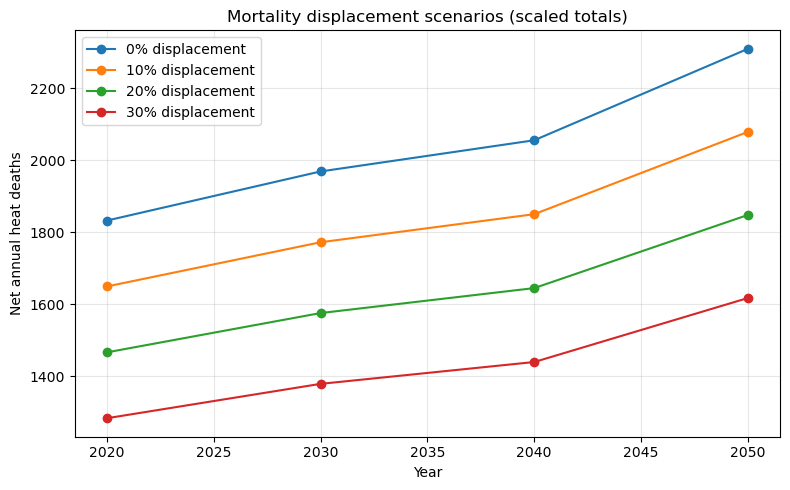

In [42]:
# 5. MORTALITY DISPLACEMENT REPORTING SCENARIOS

displacement_base_name = "scaled" if baseline_scaled is not None else "unscaled"
displacement_base_df = baseline_scaled if baseline_scaled is not None else baseline_unscaled

displacement_fractions = [0.0, 0.10, 0.20, 0.30]
displacement_rows = []

for frac in displacement_fractions:
    for year in YEARS:
        gross_total = float(displacement_base_df.loc[year, "total"])
        net_total = gross_total * (1.0 - frac)

        displacement_rows.append({
            "year": year,
            "base_series": displacement_base_name,
            "displacement_frac": frac,
            "gross_total": gross_total,
            "net_total": net_total,
            "reduction": gross_total - net_total,
        })

displacement_df = pd.DataFrame(displacement_rows)

print(f"Mortality displacement scenarios (applied to {displacement_base_name} totals):")
display(displacement_df)

displacement_df.to_csv(table_dir / f"{SLUG}_sensitivity_displacement.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
for frac in displacement_fractions:
    sub = displacement_df[displacement_df["displacement_frac"] == frac].sort_values("year")
    ax.plot(sub["year"], sub["net_total"], marker="o", label=f"{int(frac*100)}% displacement")
ax.set_xlabel("Year")
ax.set_ylabel("Net annual heat deaths")
ax.set_title(f"Mortality displacement scenarios ({displacement_base_name} totals)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir / f"{SLUG}_sensitivity_displacement.png", dpi=150, bbox_inches="tight")
plt.show()

### 7. Sensitivity synthesis

Finally, the notebook gathers the main sensitivity outputs into a compact table and figure that can be reused in later documentation, discussion, and uncertainty analysis.


Summary table:


,year,component,value
0,2020,baseline_unscaled,1832.464629
1,2030,baseline_unscaled,2279.323615
2,2040,baseline_unscaled,2695.048737
3,2050,baseline_unscaled,3234.521935
4,2020,baseline_scaled,1832.464629
5,2030,baseline_scaled,1969.112896
6,2040,baseline_scaled,2055.881779
7,2050,baseline_scaled,2310.227582
8,2020,param_low_0.8x,1465.971703
9,2020,param_high_1.2x,2198.957555


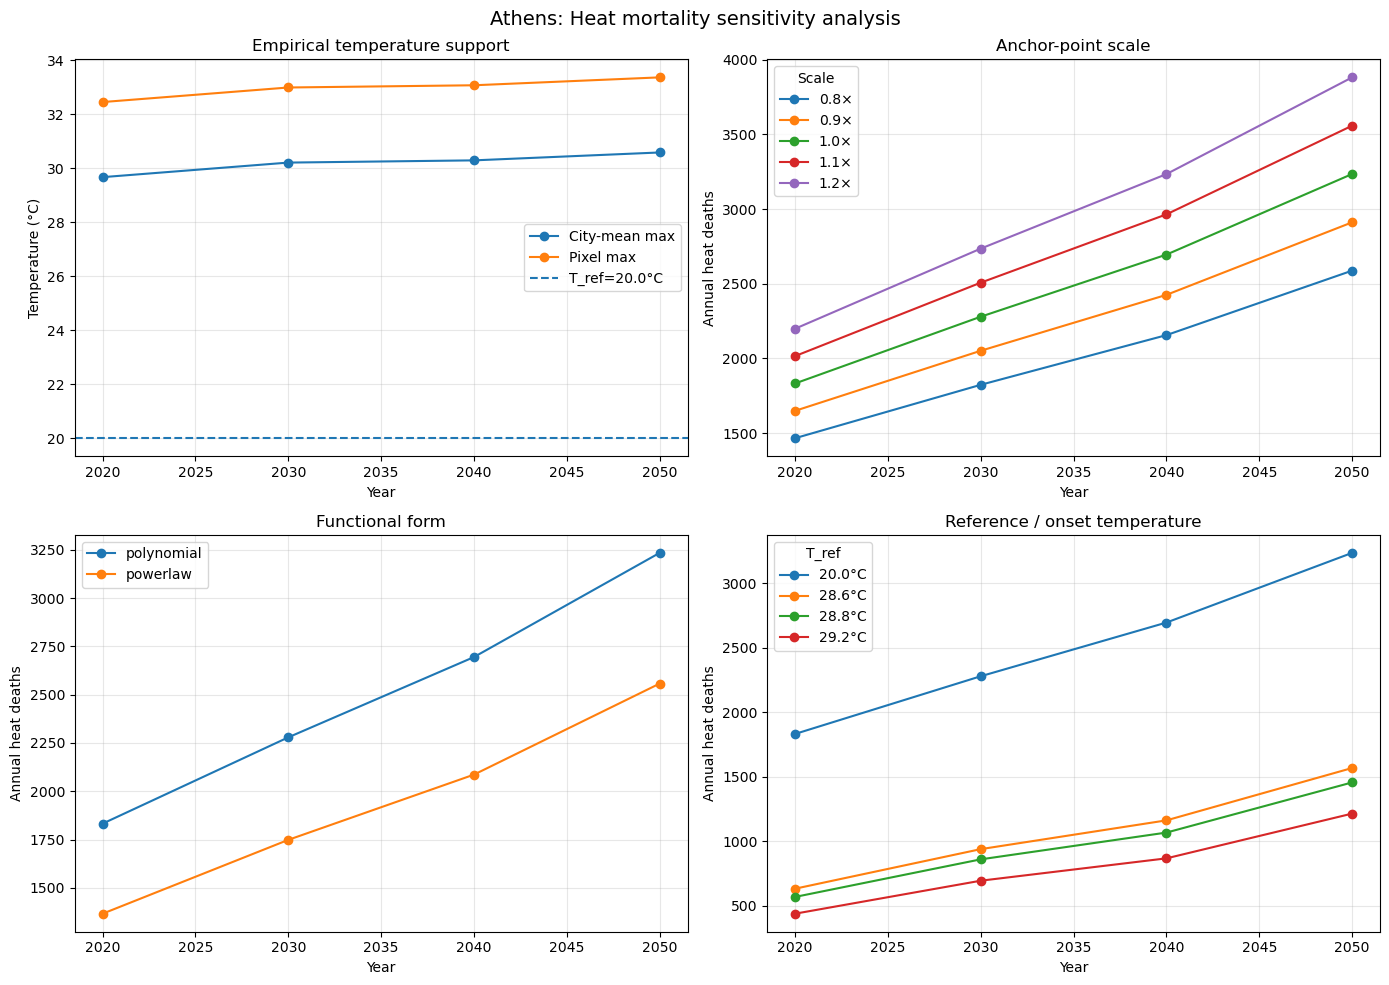

Saved summary figure to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/figures/athens_sensitivity_summary.png
Saved summary table to:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/athens/tables/athens_sensitivity_summary.csv


In [43]:
# 7. SUMMARY TABLES AND SYNTHESIS FIGURE

summary_records = []

# baseline
for year in YEARS:
    summary_records.append({
        "year": year,
        "component": "baseline_unscaled",
        "value": float(baseline_unscaled.loc[year, "total"]),
    })

if baseline_scaled is not None:
    for year in YEARS:
        summary_records.append({
            "year": year,
            "component": "baseline_scaled",
            "value": float(baseline_scaled.loc[year, "total"]),
        })

# parameter sensitivity extremes
for year in YEARS:
    sub = param_sensitivity_df[param_sensitivity_df["year"] == year]
    summary_records.append({
        "year": year,
        "component": "param_low_0.8x",
        "value": float(sub.loc[sub["scale"] == 0.8, "total"].iloc[0]),
    })
    summary_records.append({
        "year": year,
        "component": "param_high_1.2x",
        "value": float(sub.loc[sub["scale"] == 1.2, "total"].iloc[0]),
    })

# functional form
for year in YEARS:
    sub = functional_form_df[functional_form_df["year"] == year]
    for form in ["polynomial", "powerlaw"]:
        summary_records.append({
            "year": year,
            "component": f"form_{form}",
            "value": float(sub.loc[sub["functional_form"] == form, "total"].iloc[0]),
        })

# tref extremes
for year in YEARS:
    sub = tref_sensitivity_df[tref_sensitivity_df["year"] == year]
    low_row = sub.sort_values("T_ref_test").iloc[0]
    high_row = sub.sort_values("T_ref_test").iloc[-1]
    summary_records.append({
        "year": year,
        "component": f"tref_low_{low_row['T_ref_test']:.1f}",
        "value": float(low_row["total"]),
    })
    summary_records.append({
        "year": year,
        "component": f"tref_high_{high_row['T_ref_test']:.1f}",
        "value": float(high_row["total"]),
    })

summary_df = pd.DataFrame(summary_records)
summary_df.to_csv(table_dir / f"{SLUG}_sensitivity_summary.csv", index=False)

print("Summary table:")
display(summary_df)

# 2x2 summary figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: empirical support
ax = axes[0, 0]
ax.plot(support_df.index, support_df["citymean_max"], marker="o", label="City-mean max")
ax.plot(support_df.index, support_df["pixel_max"], marker="o", label="Pixel max")
ax.axhline(float(T_ref), linestyle="--", label=f"T_ref={T_ref:.1f}°C")
ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Empirical temperature support")
ax.grid(True, alpha=0.3)
ax.legend()

# Panel 2: anchor scale sensitivity
ax = axes[0, 1]
for scale in param_scales:
    sub = param_sensitivity_df[param_sensitivity_df["scale"] == scale].sort_values("year")
    ax.plot(sub["year"], sub["total"], marker="o", label=f"{scale:.1f}×")
ax.set_xlabel("Year")
ax.set_ylabel("Annual heat deaths")
ax.set_title("Anchor-point scale")
ax.grid(True, alpha=0.3)
ax.legend(title="Scale")

# Panel 3: functional form
ax = axes[1, 0]
for form in ["polynomial", "powerlaw"]:
    sub = functional_form_df[functional_form_df["functional_form"] == form].sort_values("year")
    ax.plot(sub["year"], sub["total"], marker="o", label=form)
ax.set_xlabel("Year")
ax.set_ylabel("Annual heat deaths")
ax.set_title("Functional form")
ax.grid(True, alpha=0.3)
ax.legend()

# Panel 4: tref sensitivity
ax = axes[1, 1]
for _, row in tref_candidates_df.iterrows():
    sub = tref_sensitivity_df[tref_sensitivity_df["label"] == row["label"]].sort_values("year")
    ax.plot(sub["year"], sub["total"], marker="o", label=f"{row['T_ref_test']:.1f}°C")
ax.set_xlabel("Year")
ax.set_ylabel("Annual heat deaths")
ax.set_title("Reference / onset temperature")
ax.grid(True, alpha=0.3)
ax.legend(title="T_ref")

plt.suptitle(f"{CITY}: Heat mortality sensitivity analysis", fontsize=14)
plt.tight_layout()
plt.savefig(fig_dir / f"{SLUG}_sensitivity_summary.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved summary figure to: {fig_dir / f'{SLUG}_sensitivity_summary.png'}")
print(f"Saved summary table to:  {table_dir / f'{SLUG}_sensitivity_summary.csv'}")